# TFM - Segmentación inteligente de clientes bancarios

**Objetivo del notebook:** construir una matriz analítica a nivel cliente a partir de datos transaccionales de tarjeta de crédito, generar variables comportamentales, aplicar técnicas de clustering, evaluar calidad y estabilidad, e interpretar segmentos accionables para marketing.

**Dataset:** `priyamchoksi/credit-card-transactions-dataset` en Kaggle.

El análisis implementa dos capas de segmentación:

1. **Modelo general:** considera todos los clientes disponibles.
2. **Modelo elegible:** considera clientes con historial transaccional suficiente para construir perfiles comportamentales más robustos.

La comparación entre ambos enfoques permite decidir si la segmentación final debe basarse en todos los clientes o en una muestra analítica elegible.

## 1. Configuración del entorno

In [1]:
# Librerías estándar para manejo de rutas, reproducibilidad, advertencias y configuración del entorno.
import os
import sys
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew

from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

for path in [DATA_DIR, OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Directorio del proyecto:", PROJECT_DIR)
print("Directorio de datos:", DATA_DIR)
print("Directorio de salidas:", OUTPUT_DIR)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Directorio del proyecto: /content
Directorio de datos: /content/data
Directorio de salidas: /content/outputs


## 2. Descarga o carga reproducible del dataset

In [2]:
# Identificador del dataset usado en el TFM y funciones de descarga/carga reproducible.
KAGGLE_DATASET = "priyamchoksi/credit-card-transactions-dataset"

def download_with_kagglehub(dataset_slug, data_dir):
    """
    Descarga el dataset definido para el TFM mediante kagglehub y copia los archivos CSV al directorio local del proyecto.
    """
    try:
        import kagglehub
    except ImportError:
        print("kagglehub no está instalado. Instalando...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
        import kagglehub

    try:
        dataset_path = Path(kagglehub.dataset_download(dataset_slug))
        print(f"Dataset descargado con kagglehub en: {dataset_path}")

        csv_files = list(dataset_path.rglob("*.csv"))
        if not csv_files:
            print("No se encontraron archivos CSV dentro del dataset descargado.")
            return None

        for csv_file in csv_files:
            target = data_dir / csv_file.name
            if not target.exists():
                target.write_bytes(csv_file.read_bytes())
                print(f"Copiado a: {target}")

        return data_dir

    except Exception as e:
        print("No fue posible descargar con kagglehub.")
        print(f"Detalle: {e}")
        return None


def download_with_kaggle_api(dataset_slug, data_dir):
    """
    Descarga el dataset definido para el TFM mediante la API oficial de Kaggle cuando el entorno tenga credenciales configuradas.
    """
    try:
        import kaggle
    except ImportError:
        print("kaggle no está instalado. Instalando...")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle"])
        import kaggle

    try:
        kaggle.api.dataset_download_files(
            dataset_slug,
            path=str(data_dir),
            unzip=True
        )
        print(f"Dataset descargado con Kaggle API en: {data_dir}")
        return data_dir

    except Exception as e:
        print("No fue posible descargar con Kaggle API.")
        print("Verifica si tienes configurado kaggle.json.")
        print(f"Detalle: {e}")
        return None


def ensure_dataset_available(dataset_slug, data_dir):
    """
    Verifica la disponibilidad local del CSV y, cuando no exista, ejecuta la descarga reproducible del dataset.
    Orden:
    1. Buscar CSV local en /data.
    2. Intentar descarga pública con kagglehub.
    3. Intentar descarga con Kaggle API.
    4. Si falla, solicitar descarga manual.
    """
    csv_files = sorted(data_dir.glob("*.csv"))

    if csv_files:
        print("Dataset encontrado localmente.")
        return csv_files

    print("No se encontró CSV local. Intentando descarga con kagglehub...")
    download_with_kagglehub(dataset_slug, data_dir)
    csv_files = sorted(data_dir.glob("*.csv"))

    if csv_files:
        return csv_files

    print("Intentando descarga con Kaggle API...")
    download_with_kaggle_api(dataset_slug, data_dir)
    csv_files = sorted(data_dir.glob("*.csv"))

    if csv_files:
        return csv_files

    raise FileNotFoundError(
        "No fue posible descargar automáticamente el dataset. "
        "Descárgalo manualmente desde Kaggle y coloca el CSV en la carpeta /data."
    )


csv_files = ensure_dataset_available(KAGGLE_DATASET, DATA_DIR)

print("Archivos CSV disponibles:")
for i, file in enumerate(csv_files, start=1):
    print(f"{i}. {file.name} ({file.stat().st_size / (1024**2):.2f} MB)")

CSV_PATH = csv_files[0]
CSV_PATH

No se encontró CSV local. Intentando descarga con kagglehub...


100%|██████████| 145M/145M [00:01<00:00, 96.6MB/s]

Extracting files...


Dataset descargado con kagglehub en: /root/.cache/kagglehub/datasets/priyamchoksi/credit-card-transactions-dataset/versions/1
Copiado a: /content/data/credit_card_transactions.csv
Archivos CSV disponibles:
1. credit_card_transactions.csv (337.74 MB)


PosixPath('/content/data/credit_card_transactions.csv')

## 3. Carga inicial y auditoría del dataset transaccional

In [3]:
# Carga del dataset transaccional original sin modificarlo, preservando una copia bruta para auditoría.
df_raw = pd.read_csv(CSV_PATH)

print("Dimensiones iniciales:", df_raw.shape)
display(df_raw.head())

Dimensiones iniciales: (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0,"28,705.0000"
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0,"83,236.0000"
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0,"22,844.0000"


In [4]:
# Auditoría inicial de columnas: tipo de dato, valores ausentes y cardinalidad.
audit = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [df_raw[col].dtype for col in df_raw.columns],
    "missing_count": [df_raw[col].isna().sum() for col in df_raw.columns],
    "missing_pct": [df_raw[col].isna().mean() * 100 for col in df_raw.columns],
    "nunique": [df_raw[col].nunique(dropna=True) for col in df_raw.columns]
}).sort_values("missing_pct", ascending=False)

display(audit)
audit.to_csv(TABLES_DIR / "auditoria_inicial_columnas.csv", index=False)

print("Duplicados exactos:", df_raw.duplicated().sum())

,column,dtype,missing_count,missing_pct,nunique
23,merch_zipcode,float64,195973,15.1135,28336
0,Unnamed: 0,int64,0,0.0000,1296675
2,cc_num,int64,0,0.0000,983
1,trans_date_trans_time,object,0,0.0000,1274791
4,category,object,0,0.0000,14
5,amt,float64,0,0.0000,52928
6,first,object,0,0.0000,352
3,merchant,object,0,0.0000,693
7,last,object,0,0.0000,481
8,gender,object,0,0.0000,2


Duplicados exactos: 0


In [5]:
# Validación de estructura esperada del dataset frente a las columnas realmente disponibles.
expected_columns = {
    "trans_date_trans_time", "cc_num", "merchant", "category", "amt",
    "first", "last", "gender", "street", "city", "state", "zip",
    "lat", "long", "city_pop", "job", "dob", "trans_num",
    "unix_time", "merch_lat", "merch_long", "is_fraud", "merch_zipcode"
}

available_columns = set(df_raw.columns)
print("Columnas esperadas ausentes:", expected_columns - available_columns)
print("Columnas adicionales:", available_columns - expected_columns)

Columnas esperadas ausentes: set()
Columnas adicionales: {'Unnamed: 0'}


## 4. Preparación inicial y exclusión de variables no analíticas

In [6]:
# Preparación inicial: conversión de tipos, validación de campos críticos y limpieza mínima.
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

required_cols = ["cc_num", "trans_date_trans_time", "amt", "category", "merchant"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
if "dob" in df.columns:
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

df["amt"] = pd.to_numeric(df["amt"], errors="coerce")
df = df.dropna(subset=["cc_num", "trans_date_trans_time", "amt"])
df = df[df["amt"] >= 0].copy()

excluded_from_modeling = ["Unnamed: 0", "first", "last", "street", "trans_num", "is_fraud"]
existing_exclusions = [c for c in excluded_from_modeling if c in df.columns]

print("Columnas excluidas del modelado:", existing_exclusions)
print("Dimensiones tras limpieza mínima:", df.shape)
display(df.head())

Columnas excluidas del modelado: ['Unnamed: 0', 'first', 'last', 'street', 'trans_num', 'is_fraud']
Dimensiones tras limpieza mínima: (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0,"28,705.0000"
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0,"83,236.0000"
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0,"22,844.0000"


## 5. Análisis exploratorio transaccional

In [7]:
# Resumen transaccional: ventana temporal, volumen de transacciones y número de clientes.
min_date = df["trans_date_trans_time"].min()
max_date = df["trans_date_trans_time"].max()
n_transactions = len(df)
n_clients = df["cc_num"].nunique()

print("Fecha mínima:", min_date)
print("Fecha máxima:", max_date)
print("Transacciones:", n_transactions)
print("Clientes únicos:", n_clients)

txn_per_client = df.groupby("cc_num").size()
display(txn_per_client.describe())

Fecha mínima: 2019-01-01 00:00:18
Fecha máxima: 2020-06-21 12:13:37
Transacciones: 1296675
Clientes únicos: 983


,0
count,983.0000
mean,"1,319.0997"
std,812.2359
min,7.0000
25%,525.0000
50%,"1,054.0000"
75%,"2,025.0000"
max,"3,123.0000"


,amt
count,"1,296,675.0000"
mean,70.3510
std,160.3160
min,1.0000
1%,1.2600
5%,2.4400
25%,9.6500
50%,47.5200
75%,83.1400
95%,196.3100


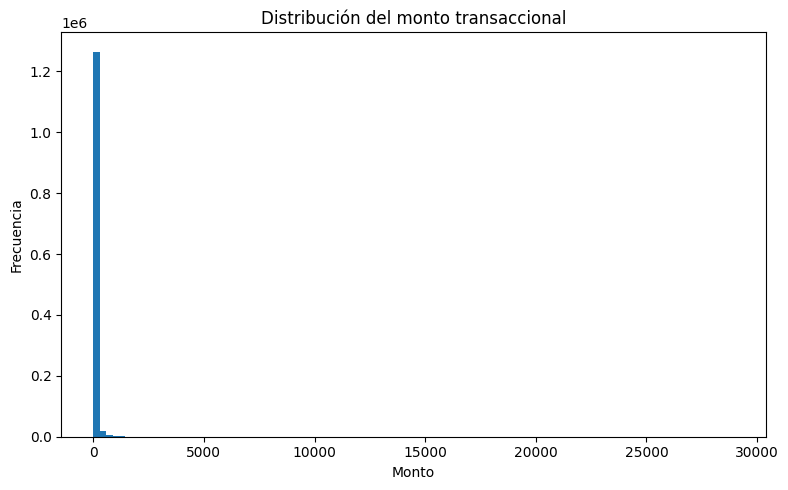

In [8]:
# Análisis de distribución del monto transaccional para identificar asimetría y valores extremos.
amount_summary = df["amt"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
display(amount_summary)

plt.figure(figsize=(8, 5))
plt.hist(df["amt"], bins=100)
plt.title("Distribución del monto transaccional")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_monto_transaccional.png", dpi=150)
plt.show()

In [9]:
# Resumen por categoría de consumo: volumen, gasto total y ticket promedio.
category_summary = (
    df.groupby("category")
    .agg(
        transactions=("amt", "size"),
        total_amount=("amt", "sum"),
        avg_amount=("amt", "mean")
    )
    .sort_values("total_amount", ascending=False)
)

display(category_summary)
category_summary.to_csv(TABLES_DIR / "resumen_categorias.csv")

,transactions,total_amount,avg_amount
category,,,
grocery_pos,123638,"14,460,822.3800",116.9610
shopping_pos,116672,"9,307,993.6100",79.7792
shopping_net,97543,"8,625,149.6800",88.4241
gas_transport,131659,"8,351,732.2900",63.4346
home,123115,"7,173,928.1100",58.2701
kids_pets,113035,"6,503,680.1600",57.5369
entertainment,94014,"6,036,678.5600",64.2104
misc_net,63287,"5,117,709.2600",80.8651
misc_pos,79655,"5,009,582.5000",62.8910


## 6. Construcción de variables a nivel cliente

In [10]:
# Derivación de variables temporales auxiliares y agregación inicial a nivel cliente.
df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["transaction_dayofweek"].isin([5, 6]).astype(int)

def time_period(hour):
    if 6 <= hour < 12:
        return "morning"
    if 12 <= hour < 18:
        return "afternoon"
    if 18 <= hour < 24:
        return "night"
    return "early_morning"

df["time_period"] = df["transaction_hour"].apply(time_period)

reference_date = df["trans_date_trans_time"].max() + pd.Timedelta(days=1)

client_base = (
    df.groupby("cc_num")
    .agg(
        first_transaction=("trans_date_trans_time", "min"),
        last_transaction=("trans_date_trans_time", "max"),
        frequency=("amt", "size"),
        monetary_total=("amt", "sum"),
        ticket_mean=("amt", "mean"),
        ticket_median=("amt", "median"),
        ticket_std=("amt", "std"),
        ticket_min=("amt", "min"),
        ticket_max=("amt", "max"),
        category_nunique=("category", "nunique"),
        merchant_nunique=("merchant", "nunique"),
        weekend_txn_pct=("is_weekend", "mean")
    )
    .reset_index()
)

client_base["recency_days"] = (reference_date - client_base["last_transaction"]).dt.days
client_base["customer_lifetime_days"] = (
    client_base["last_transaction"] - client_base["first_transaction"]
).dt.days + 1
client_base["ticket_std"] = client_base["ticket_std"].fillna(0)

display(client_base.head())
print("Matriz base cliente:", client_base.shape)

,cc_num,first_transaction,last_transaction,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days
0,60416207185,2019-01-01 12:47:15,2020-06-21 08:54:21,1518,"85,043.4700",56.0234,36.6400,122.6326,1.0200,"3,075.0900",14,575,0.3261,1,537
1,60422928733,2019-01-03 18:38:26,2020-06-21 09:19:28,1531,"105,640.2000",69.0008,52.4600,102.6820,1.0400,"1,290.3700",14,578,0.3370,1,535
2,60423098130,2019-01-01 06:48:36,2020-06-19 01:14:31,510,"58,673.6300",115.0463,35.3000,"1,202.9880",1.0100,"27,119.7700",14,338,0.3353,3,535
3,60427851591,2019-01-01 07:36:27,2020-06-19 13:06:04,528,"59,129.6100",111.9879,76.7050,143.3107,8.8600,"1,164.3600",14,358,0.3144,2,536
4,60487002085,2019-01-06 03:23:55,2020-06-20 15:44:36,496,"25,160.1100",50.7260,35.6400,65.8440,1.0200,750.3900,14,346,0.3226,1,532


Matriz base cliente: (983, 15)


In [11]:
# Construcción de variables de distribución horaria, diversidad y concentración de consumo.
period_pivot = (
    df.pivot_table(index="cc_num", columns="time_period", values="amt", aggfunc="size", fill_value=0)
)
period_pivot = period_pivot.div(period_pivot.sum(axis=1), axis=0)
period_pivot.columns = [f"txn_pct_{col}" for col in period_pivot.columns]

client_category = (
    df.groupby(["cc_num", "category"])
    .agg(category_amount=("amt", "sum"), category_txn=("amt", "size"))
    .reset_index()
)

total_by_client = client_category.groupby("cc_num")["category_amount"].transform("sum")
client_category["category_amount_share"] = client_category["category_amount"] / total_by_client

category_concentration = (
    client_category.sort_values(["cc_num", "category_amount_share"], ascending=[True, False])
    .groupby("cc_num")
    .agg(
        top_category_share=("category_amount_share", "max"),
        top3_category_share=("category_amount_share", lambda x: x.head(3).sum())
    )
)

dominant_category = (
    client_category.sort_values(["cc_num", "category_amount_share"], ascending=[True, False])
    .groupby("cc_num")
    .first()[["category"]]
    .rename(columns={"category": "dominant_category"})
)

client_features = (
    client_base
    .set_index("cc_num")
    .join(period_pivot, how="left")
    .join(category_concentration, how="left")
    .join(dominant_category, how="left")
    .reset_index()
)

client_features = client_features.fillna(0)

display(client_features.head())
print("Matriz cliente con variables:", client_features.shape)
client_features.to_csv(TABLES_DIR / "matriz_cliente_features.csv", index=False)

,cc_num,first_transaction,last_transaction,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share,dominant_category
0,60416207185,2019-01-01 12:47:15,2020-06-21 08:54:21,1518,"85,043.4700",56.0234,36.6400,122.6326,1.0200,"3,075.0900",14,575,0.3261,1,537,0.3597,0.1489,0.1561,0.3353,0.1722,0.4558,grocery_pos
1,60422928733,2019-01-03 18:38:26,2020-06-21 09:19:28,1531,"105,640.2000",69.0008,52.4600,102.6820,1.0400,"1,290.3700",14,578,0.3370,1,535,0.2051,0.3063,0.2900,0.1986,0.1395,0.3481,grocery_pos
2,60423098130,2019-01-01 06:48:36,2020-06-19 01:14:31,510,"58,673.6300",115.0463,35.3000,"1,202.9880",1.0100,"27,119.7700",14,338,0.3353,3,535,0.2569,0.2176,0.2314,0.2941,0.4644,0.6450,travel
3,60427851591,2019-01-01 07:36:27,2020-06-19 13:06:04,528,"59,129.6100",111.9879,76.7050,143.3107,8.8600,"1,164.3600",14,358,0.3144,2,536,0.2614,0.2159,0.2765,0.2462,0.1814,0.4743,travel
4,60487002085,2019-01-06 03:23:55,2020-06-20 15:44:36,496,"25,160.1100",50.7260,35.6400,65.8440,1.0200,750.3900,14,346,0.3226,1,532,0.3327,0.1552,0.1673,0.3448,0.1601,0.4200,grocery_pos


Matriz cliente con variables: (983, 22)


## 7. Funciones auxiliares

In [12]:
# Funciones auxiliares para selección de variables, preprocesamiento, evaluación y perfilado de segmentos.
def select_model_features(client_df):
    """Selecciona variables numéricas candidatas para clustering."""
    non_model_columns = ["cc_num", "first_transaction", "last_transaction", "dominant_category"]
    model_features = [c for c in client_df.columns if c not in non_model_columns]
    X = client_df[model_features].copy()
    X = X.select_dtypes(include=[np.number]).copy()
    return X, X.columns.tolist()


def compute_skewness(X_df):
    """Calcula asimetría de variables numéricas."""
    skewness = X_df.apply(lambda s: skew(s.dropna()) if s.dropna().nunique() > 1 else 0).sort_values(ascending=False)
    out = skewness.reset_index()
    out.columns = ["feature", "skewness"]
    return out


def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    """Limita valores extremos a percentiles para reducir influencia de outliers sin eliminar clientes."""
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower=lower, upper=upper)


def classify_feature_roles(columns):
    """
    Clasifica variables por rol analítico para evitar transformar de forma indiscriminada
    variables monetarias, conteos, proporciones y variables temporales.
    """
    roles = {}

    monetary_features = {
        "monetary_total",
        "ticket_mean",
        "ticket_median",
        "ticket_std",
        "ticket_max"
    }

    # ticket_min se excluye por baja utilidad de negocio y riesgo de inestabilidad de escala:
    # suele tener variabilidad central muy baja y puede dominar el RobustScaler.
    excluded_features = {"ticket_min"}

    intensity_features = {
        "frequency"
    }

    diversity_features = {
        "category_nunique",
        "merchant_nunique"
    }

    temporal_features = {
        "recency_days",
        "customer_lifetime_days"
    }

    for col in columns:
        if col in excluded_features:
            roles[col] = "excluded"
        elif col in monetary_features:
            roles[col] = "monetary"
        elif col in intensity_features:
            roles[col] = "intensity"
        elif col in diversity_features:
            roles[col] = "diversity"
        elif col in temporal_features:
            roles[col] = "temporal"
        elif col.endswith("_pct") or col.endswith("_share") or "pct_" in col:
            roles[col] = "proportion"
        else:
            roles[col] = "other"

    return roles


def preprocess_feature_matrix(
    X_df,
    transform_method="log",
    skew_threshold=1.0,
    winsor_lower=0.01,
    winsor_upper=0.99,
    drop_zero_variance=True,
    drop_excluded=True
):
    """
    Preprocesamiento selectivo para clustering.

    Principios metodológicos:
    1. No transformar todas las variables de forma automática.
    2. Aplicar transformaciones logarítmicas únicamente a variables monetarias o de intensidad
       cuando la asimetría lo justifique.
    3. No aplicar log a proporciones o porcentajes, porque ya están acotadas entre 0 y 1.
    4. Excluir variables con baja utilidad analítica y potencial inestabilidad de escala.
    5. Mantener trazabilidad de columnas winsorizadas, transformadas, excluidas y eliminadas.
    """
    X_processed = X_df.copy()
    metadata = {}

    feature_roles = classify_feature_roles(X_processed.columns)
    metadata["feature_roles"] = pd.DataFrame({
        "feature": list(feature_roles.keys()),
        "role": list(feature_roles.values())
    })

    excluded_by_role = [col for col, role in feature_roles.items() if role == "excluded"]

    if drop_excluded and excluded_by_role:
        X_processed = X_processed.drop(columns=excluded_by_role)
    metadata["excluded_by_role"] = excluded_by_role if drop_excluded else []

    skewness_df = compute_skewness(X_processed)
    skew_map = dict(zip(skewness_df["feature"], skewness_df["skewness"]))
    metadata["skewness_before"] = skewness_df

    # Winsorización selectiva: solo variables de monto, intensidad y diversidad de comercios.
    # Las proporciones se mantienen en escala natural y luego se escalan.
    winsor_roles = {"monetary", "intensity", "diversity"}
    candidate_winsor_cols = [
        col for col in X_processed.columns
        if feature_roles.get(col) in winsor_roles
    ]

    for col in candidate_winsor_cols:
        X_processed[col] = winsorize_series(X_processed[col], winsor_lower, winsor_upper)

    metadata["winsorized_columns"] = candidate_winsor_cols

    # Transformación selectiva: solo monetarias e intensidad con asimetría positiva.
    # No se transforman proporciones, cuotas, variables temporales ni variables con asimetría negativa.
    transform_roles = {"monetary", "intensity"}
    high_positive_skew_cols = [
        col for col in X_processed.columns
        if feature_roles.get(col) in transform_roles
        and skew_map.get(col, 0) > skew_threshold
        and (X_processed[col] >= 0).all()
    ]

    transformed_cols = []

    if transform_method == "log":
        transformed_cols = high_positive_skew_cols
        for col in transformed_cols:
            X_processed[col] = np.log1p(X_processed[col])

    elif transform_method == "yeo-johnson":
        transformed_cols = high_positive_skew_cols
        if transformed_cols:
            pt = PowerTransformer(method="yeo-johnson", standardize=False)
            X_processed[transformed_cols] = pt.fit_transform(X_processed[transformed_cols])

    elif transform_method == "none":
        transformed_cols = []
    else:
        raise ValueError("transform_method debe ser 'log', 'yeo-johnson' o 'none'.")

    metadata["transformed_columns"] = transformed_cols
    metadata["transform_method"] = transform_method

    if drop_zero_variance:
        nunique = X_processed.nunique(dropna=True)
        zero_var_cols = nunique[nunique <= 1].index.tolist()
        X_processed = X_processed.drop(columns=zero_var_cols)
        metadata["dropped_zero_variance_columns"] = zero_var_cols
    else:
        metadata["dropped_zero_variance_columns"] = []

    metadata["skewness_after"] = compute_skewness(X_processed)

    return X_processed, metadata


def scale_features(X_df, scaler_type="robust"):
    """
    Escala variables para clustering.

    Se utiliza RobustScaler con rango 5-95 en vez del IQR 25-75 por defecto.
    Esto reduce el riesgo de explosión de escala en variables cuya variabilidad central
    es extremadamente pequeña, manteniendo resistencia a outliers.
    """
    if scaler_type == "robust":
        scaler = RobustScaler(quantile_range=(5.0, 95.0))
    elif scaler_type == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError("scaler_type debe ser 'robust' o 'standard'.")

    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_df),
        columns=X_df.columns,
        index=X_df.index
    )
    return X_scaled, scaler


def evaluate_clustering(X_matrix, labels):
    """Calcula métricas internas de clustering."""
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)

    if n_clusters < 2 or n_clusters >= len(labels):
        return {
            "n_clusters": n_clusters,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan
        }

    return {
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X_matrix, labels),
        "davies_bouldin": davies_bouldin_score(X_matrix, labels),
        "calinski_harabasz": calinski_harabasz_score(X_matrix, labels)
    }


def run_kmeans_grid(X_scaled, k_range=range(3, 11), label="KMeans"):
    """Evalúa K-Means para un rango de k."""
    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        labels = model.fit_predict(X_scaled)
        metrics = evaluate_clustering(X_scaled, labels)
        metrics["k"] = k
        metrics["model"] = label
        metrics["inertia"] = model.inertia_
        rows.append(metrics)
    return pd.DataFrame(rows)


def run_agglomerative_grid(X_scaled, k_range=range(3, 11), label="Agglomerative_Ward"):
    """Evalúa clustering jerárquico aglomerativo para un rango de k."""
    rows = []
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(X_scaled)
        metrics = evaluate_clustering(X_scaled, labels)
        metrics["k"] = k
        metrics["model"] = label
        rows.append(metrics)
    return pd.DataFrame(rows)


def stability_by_seed(X_matrix, k, seeds):
    """Evalúa estabilidad de K-Means ante distintas semillas mediante ARI."""
    labels_by_seed = {}

    for seed in seeds:
        model = KMeans(n_clusters=k, random_state=seed, n_init=20)
        labels_by_seed[seed] = model.fit_predict(X_matrix)

    rows = []
    for i, seed_a in enumerate(seeds):
        for seed_b in seeds[i + 1:]:
            rows.append({
                "seed_a": seed_a,
                "seed_b": seed_b,
                "ari": adjusted_rand_score(labels_by_seed[seed_a], labels_by_seed[seed_b])
            })

    return pd.DataFrame(rows)


def bootstrap_stability_kmeans(X_df, k, n_iterations=20, sample_frac=0.80):
    """Evalúa estabilidad mediante remuestreo aleatorio y ARI contra partición de referencia."""
    rng = np.random.default_rng(RANDOM_STATE)

    reference_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    reference_labels = reference_model.fit_predict(X_df)
    reference_labels = pd.Series(reference_labels, index=X_df.index)

    rows = []
    for i in range(n_iterations):
        sample_idx = rng.choice(X_df.index, size=int(len(X_df) * sample_frac), replace=False)
        X_sample = X_df.loc[sample_idx]

        model = KMeans(n_clusters=k, random_state=RANDOM_STATE + i, n_init=20)
        sample_labels = model.fit_predict(X_sample)

        reference_sample_labels = reference_labels.loc[sample_idx].values

        rows.append({
            "iteration": i + 1,
            "sample_size": len(sample_idx),
            "ari_vs_reference": adjusted_rand_score(reference_sample_labels, sample_labels)
        })

    return pd.DataFrame(rows)


def build_segment_profiles(client_df, X_original, labels):
    """Construye base segmentada, tamaños, perfil promedio e índices vs promedio."""
    out = client_df.copy()
    out["segment_id"] = labels

    sizes = out["segment_id"].value_counts().sort_index().rename("n_clients").to_frame()
    sizes["pct_clients"] = sizes["n_clients"] / len(out) * 100

    profile_features = X_original.columns.tolist()
    profile = out.groupby("segment_id")[profile_features].mean()
    overall_profile = out[profile_features].mean()
    profile_index = profile.div(overall_profile.replace(0, np.nan), axis=1)

    return out, sizes, profile, profile_index


def get_dominant_variables(profile_index, top_high_n=8, top_low_n=5):
    """Identifica variables por encima y por debajo del promedio global para cada segmento."""
    rows = []
    for segment in profile_index.index:
        values = profile_index.loc[segment].dropna()
        top_high = values.sort_values(ascending=False).head(top_high_n)
        top_low = values.sort_values(ascending=True).head(top_low_n)

        for feature, value in top_high.items():
            rows.append({
                "segment_id": segment,
                "direction": "above_average",
                "feature": feature,
                "index_vs_average": value
            })

        for feature, value in top_low.items():
            rows.append({
                "segment_id": segment,
                "direction": "below_average",
                "feature": feature,
                "index_vs_average": value
            })

    return pd.DataFrame(rows)

## 7.1 Ajuste metodológico del preprocesamiento

Se aplica un preprocesamiento selectivo. Las transformaciones logarítmicas se limitan a variables monetarias o de intensidad cuando la asimetría positiva lo justifica. Las proporciones, porcentajes y variables de concentración se mantienen en su escala natural para evitar distorsiones interpretativas. Además, `ticket_min` se excluye del modelado por su baja utilidad de negocio y por el riesgo de inestabilidad de escala observado durante la revisión del comportamiento de las variables.


## 8. Modelo general sobre todos los clientes

In [13]:
# Selección de variables numéricas para el modelo general sobre todos los clientes.
X_all, model_features = select_model_features(client_features)

print("Clientes:", X_all.shape[0])
print("Variables candidatas:", X_all.shape[1])
display(X_all.head())

Clientes: 983
Variables candidatas: 18


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
0,1518,"85,043.4700",56.0234,36.6400,122.6326,1.0200,"3,075.0900",14,575,0.3261,1,537,0.3597,0.1489,0.1561,0.3353,0.1722,0.4558
1,1531,"105,640.2000",69.0008,52.4600,102.6820,1.0400,"1,290.3700",14,578,0.3370,1,535,0.2051,0.3063,0.2900,0.1986,0.1395,0.3481
2,510,"58,673.6300",115.0463,35.3000,"1,202.9880",1.0100,"27,119.7700",14,338,0.3353,3,535,0.2569,0.2176,0.2314,0.2941,0.4644,0.6450
3,528,"59,129.6100",111.9879,76.7050,143.3107,8.8600,"1,164.3600",14,358,0.3144,2,536,0.2614,0.2159,0.2765,0.2462,0.1814,0.4743
4,496,"25,160.1100",50.7260,35.6400,65.8440,1.0200,750.3900,14,346,0.3226,1,532,0.3327,0.1552,0.1673,0.3448,0.1601,0.4200


In [14]:
# Preprocesamiento selectivo del modelo general: winsorización, transformación y exclusión controlada.
X_all_processed, metadata_all = preprocess_feature_matrix(
    X_all,
    transform_method="log",
    skew_threshold=1.0,
    winsor_lower=0.01,
    winsor_upper=0.99,
    drop_zero_variance=True
)

display(metadata_all["skewness_before"])
display(metadata_all["skewness_after"])

print("Variables winsorizadas:", metadata_all["winsorized_columns"])
print("Variables transformadas:", metadata_all["transformed_columns"])
print("Variables eliminadas por varianza cero:", metadata_all["dropped_zero_variance_columns"])

metadata_all["skewness_before"].to_csv(TABLES_DIR / "asimetria_variables_cliente_general_antes.csv", index=False)
metadata_all["skewness_after"].to_csv(TABLES_DIR / "asimetria_variables_cliente_general_despues.csv", index=False)

,feature,skewness
0,recency_days,4.4651
1,ticket_median,4.0468
2,ticket_max,3.8918
3,ticket_std,3.6175
4,ticket_mean,3.5754
5,top_category_share,3.3923
6,top3_category_share,2.6974
7,txn_pct_night,2.4067
8,weekend_txn_pct,2.1149
9,txn_pct_early_morning,1.1861


,feature,skewness
0,recency_days,4.4651
1,top_category_share,3.3923
2,ticket_mean,2.7727
3,ticket_median,2.7205
4,top3_category_share,2.6974
5,txn_pct_night,2.4067
6,weekend_txn_pct,2.1149
7,ticket_std,1.1911
8,txn_pct_early_morning,1.1861
9,ticket_max,0.8382


Variables winsorizadas: ['frequency', 'monetary_total', 'ticket_mean', 'ticket_median', 'ticket_std', 'ticket_max', 'category_nunique', 'merchant_nunique']
Variables transformadas: ['ticket_mean', 'ticket_median', 'ticket_std', 'ticket_max']
Variables eliminadas por varianza cero: []


,component,explained_variance_ratio,cumulative_variance
0,1,0.3748,0.3748
1,2,0.3404,0.7152
2,3,0.1222,0.8374
3,4,0.0581,0.8955
4,5,0.0427,0.9382
5,6,0.0240,0.9622
6,7,0.0140,0.9763
7,8,0.0088,0.9850
8,9,0.0069,0.9920
9,10,0.0028,0.9948


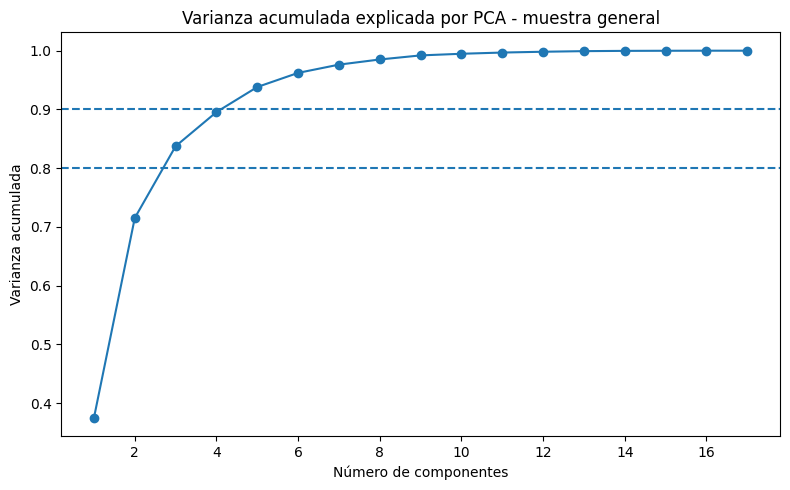

In [15]:
# Preprocesamiento selectivo del modelo general: winsorización, transformación y exclusión controlada.
X_all_scaled, scaler_all = scale_features(X_all_processed, scaler_type="robust")

pca_all = PCA(random_state=RANDOM_STATE)
pca_all.fit(X_all_scaled)

explained_all = pd.DataFrame({
    "component": np.arange(1, len(pca_all.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_all.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_all.explained_variance_ratio_)
})

display(explained_all)
explained_all.to_csv(TABLES_DIR / "pca_varianza_general.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(explained_all["component"], explained_all["cumulative_variance"], marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.title("Varianza acumulada explicada por PCA - muestra general")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_varianza_general.png", dpi=150)
plt.show()

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,k,model,inertia
0,3,0.7463,0.5917,854.2118,3,KMeans_All,865.6636
1,4,0.3452,0.9329,852.5353,4,KMeans_All,657.3804
2,5,0.3466,0.9998,770.4577,5,KMeans_All,572.0733
3,6,0.3069,1.0675,716.1509,6,KMeans_All,509.0546
4,7,0.2812,1.1170,679.5632,7,KMeans_All,458.6577
5,8,0.2763,1.1656,655.5121,8,KMeans_All,416.1699
6,9,0.2760,1.1551,639.0317,9,KMeans_All,380.0403
7,10,0.2694,1.2015,607.3411,10,KMeans_All,358.8480


,n_clusters,silhouette,davies_bouldin,calinski_harabasz,k,model
0,3,0.7460,0.6059,847.7812,3,Agglomerative_All
1,4,0.3452,0.9457,842.8408,4,Agglomerative_All
2,5,0.3451,1.0072,758.2912,5,Agglomerative_All
3,6,0.3034,1.1247,687.0034,6,Agglomerative_All
4,7,0.2861,1.1141,644.5070,7,Agglomerative_All
5,8,0.2768,1.1887,612.9604,8,Agglomerative_All
6,9,0.2471,1.2542,590.0907,9,Agglomerative_All
7,10,0.2687,1.2024,575.9343,10,Agglomerative_All


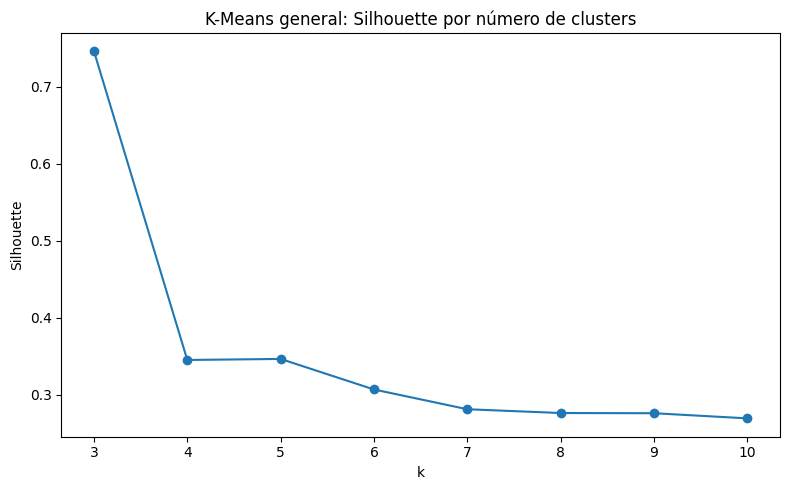

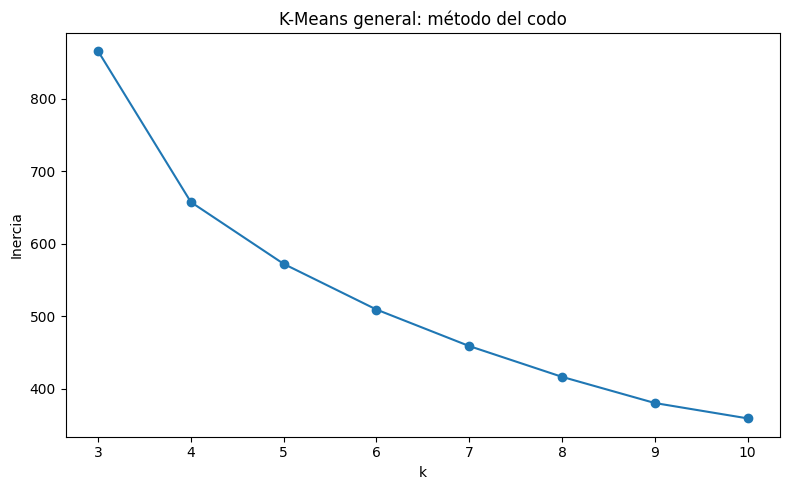

In [16]:
# Escalado robusto y análisis PCA para evaluar la estructura dimensional del modelo general.
kmeans_all_df = run_kmeans_grid(X_all_scaled, range(3, 11), "KMeans_All")
agg_all_df = run_agglomerative_grid(X_all_scaled, range(3, 11), "Agglomerative_All")

display(kmeans_all_df)
display(agg_all_df)

kmeans_all_df.to_csv(TABLES_DIR / "evaluacion_kmeans_general.csv", index=False)
agg_all_df.to_csv(TABLES_DIR / "evaluacion_agglomerative_general.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(kmeans_all_df["k"], kmeans_all_df["silhouette"], marker="o")
plt.title("K-Means general: Silhouette por número de clusters")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_general_silhouette_por_k.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_all_df["k"], kmeans_all_df["inertia"], marker="o")
plt.title("K-Means general: método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_general_elbow.png", dpi=150)
plt.show()

In [17]:
# Escalado robusto y análisis PCA para evaluar la estructura dimensional del modelo general.
try:
    import hdbscan

    hdbscan_all_rows = []
    for min_cluster_size in [10, 20, 30, 50, 75, 100]:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric="euclidean")
        labels = clusterer.fit_predict(X_all_scaled)
        noise_pct = np.mean(labels == -1) * 100
        valid_mask = labels != -1

        if valid_mask.sum() > 2 and len(np.unique(labels[valid_mask])) >= 2:
            metrics = evaluate_clustering(X_all_scaled.loc[valid_mask], labels[valid_mask])
        else:
            metrics = {
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan
            }

        metrics["model"] = "HDBSCAN_All"
        metrics["min_cluster_size"] = min_cluster_size
        metrics["noise_pct"] = noise_pct
        hdbscan_all_rows.append(metrics)

    hdbscan_all_df = pd.DataFrame(hdbscan_all_rows)
    display(hdbscan_all_df)
    hdbscan_all_df.to_csv(TABLES_DIR / "evaluacion_hdbscan_general.csv", index=False)

except ImportError:
    print("hdbscan no está instalado. Si deseas ejecutar esta sección: pip install hdbscan")

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,model,min_cluster_size,noise_pct
0,3,0.7532,0.5253,753.7090,HDBSCAN_All,10,1.9329
1,2,0.7621,0.4999,894.7830,HDBSCAN_All,20,3.8657
2,2,0.3896,1.0816,506.3685,HDBSCAN_All,30,29.7050
3,2,0.4416,0.9153,530.9021,HDBSCAN_All,50,43.0315
4,2,0.4711,0.8145,500.3714,HDBSCAN_All,75,51.0682
5,2,0.4874,0.7571,430.8202,HDBSCAN_All,100,57.5788


In [18]:
# Escalado robusto y análisis PCA para evaluar la estructura dimensional del modelo general.
best_k_all = int(kmeans_all_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("k seleccionado en modelo general según Silhouette:", best_k_all)

seed_list = [1, 7, 21, 42, 99, 123]
stability_seed_all_df = stability_by_seed(X_all_scaled, best_k_all, seed_list)
bootstrap_stability_all_df = bootstrap_stability_kmeans(X_all_scaled, best_k_all, n_iterations=20, sample_frac=0.80)

display(stability_seed_all_df)
display(bootstrap_stability_all_df.describe())

stability_seed_all_df.to_csv(TABLES_DIR / "estabilidad_kmeans_semillas_general.csv", index=False)
bootstrap_stability_all_df.to_csv(TABLES_DIR / "estabilidad_kmeans_bootstrap_general.csv", index=False)

k seleccionado en modelo general según Silhouette: 3


,seed_a,seed_b,ari
0,1,7,1.0000
1,1,21,1.0000
2,1,42,1.0000
3,1,99,1.0000
4,1,123,1.0000
5,7,21,1.0000
6,7,42,1.0000
7,7,99,1.0000
8,7,123,1.0000
9,21,42,1.0000


,iteration,sample_size,ari_vs_reference
count,20.0000,20.0000,20.0000
mean,10.5000,786.0000,0.9997
std,5.9161,0.0000,0.0007
min,1.0000,786.0000,0.9978
25%,5.7500,786.0000,1.0000
50%,10.5000,786.0000,1.0000
75%,15.2500,786.0000,1.0000
max,20.0000,786.0000,1.0000


In [19]:
# Escalado robusto y análisis PCA para evaluar la estructura dimensional del modelo general.
final_all_model = KMeans(n_clusters=best_k_all, random_state=RANDOM_STATE, n_init=20)
labels_all = final_all_model.fit_predict(X_all_scaled)

client_segments_all, segment_sizes_all, segment_profile_all, segment_profile_index_all = build_segment_profiles(
    client_features,
    X_all,
    labels_all
)

dominant_vars_all_df = get_dominant_variables(segment_profile_index_all)

display(segment_sizes_all)
display(segment_profile_all)
display(segment_profile_index_all)
display(dominant_vars_all_df)

client_segments_all.to_csv(TABLES_DIR / "clientes_segmentados_general.csv", index=False)
segment_sizes_all.to_csv(TABLES_DIR / "segment_sizes_general.csv")
segment_profile_all.to_csv(TABLES_DIR / "perfil_segmentos_promedio_general.csv")
segment_profile_index_all.to_csv(TABLES_DIR / "perfil_segmentos_indice_vs_promedio_general.csv")
dominant_vars_all_df.to_csv(TABLES_DIR / "variables_dominantes_por_segmento_general.csv", index=False)

,n_clients,pct_clients
segment_id,,
0,909,92.4720
1,30,3.0519
2,44,4.4761


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,"1,425.6821","99,873.5043",71.3294,46.2204,141.2723,2.4084,"2,907.4275",13.9923,526.2431,0.3474,1.2750,536.3399,0.2877,0.2103,0.2088,0.2932,0.1776,0.4187
1,9.8667,"6,338.1577",646.0946,667.3033,376.4207,74.7790,"1,090.8807",4.7333,9.7333,0.8455,242.5000,2.0000,0.0814,0.2953,0.0172,0.6061,0.5482,0.9441
2,9.8636,"5,619.7450",565.6019,576.0686,379.5342,41.3827,"1,049.1657",5.1591,9.6591,0.0407,303.7727,1.9773,0.0766,0.3114,0.0269,0.5851,0.5212,0.9295


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,1.0808,1.0762,0.6426,0.5200,0.8879,0.3786,1.0501,1.0509,1.0798,0.9958,0.0575,1.0811,1.0579,0.9673,1.0718,0.9284,0.8694,0.9150
1,0.0075,0.0683,5.8210,7.5069,2.3657,11.7548,0.3940,0.3555,0.0200,2.4235,10.9347,0.0040,0.2991,1.3582,0.0884,1.9191,2.6836,2.0630
2,0.0075,0.0606,5.0958,6.4806,2.3853,6.5051,0.3789,0.3875,0.0198,0.1168,13.6976,0.0040,0.2816,1.4323,0.1380,1.8526,2.5510,2.0310


,segment_id,direction,feature,index_vs_average
0,0,above_average,customer_lifetime_days,1.0811
1,0,above_average,frequency,1.0808
2,0,above_average,merchant_nunique,1.0798
3,0,above_average,monetary_total,1.0762
4,0,above_average,txn_pct_morning,1.0718
5,0,above_average,txn_pct_afternoon,1.0579
6,0,above_average,category_nunique,1.0509
7,0,above_average,ticket_max,1.0501
8,0,below_average,recency_days,0.0575
9,0,below_average,ticket_min,0.3786


## 9. Control de elegibilidad para segmentación robusta

In [20]:
# Evaluación de suficiencia de historial transaccional por cliente.
eligibility_summary = client_features[[
    "frequency",
    "customer_lifetime_days",
    "recency_days",
    "monetary_total",
    "ticket_mean",
    "category_nunique",
    "merchant_nunique"
]].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

display(eligibility_summary)
eligibility_summary.to_csv(TABLES_DIR / "eligibility_summary.csv")

,frequency,customer_lifetime_days,recency_days,monetary_total,ticket_mean,category_nunique,merchant_nunique
count,983.0000,983.0000,983.0000,983.0000,983.0000,983.0000,983.0000
mean,"1,319.0997",496.1139,22.1770,"92,800.0294",110.9947,13.3143,487.3571
std,812.2359,142.0909,87.0799,"59,584.7788",146.5958,2.4063,174.6727
min,7.0000,1.0000,1.0000,"1,348.5300",42.9517,2.0000,6.0000
1%,7.8200,2.0000,1.0000,"3,814.6480",48.9283,4.0000,7.8200
5%,10.1000,2.0000,1.0000,"6,739.2460",54.2955,5.0000,10.0000
10%,497.2000,533.0000,1.0000,"30,204.6780",56.8549,14.0000,338.0000
25%,525.0000,536.0000,1.0000,"43,554.9900",61.0145,14.0000,357.0000
50%,"1,054.0000",537.0000,1.0000,"88,514.2400",67.5582,14.0000,524.0000
75%,"2,025.0000",538.0000,1.0000,"126,784.2100",87.8606,14.0000,614.0000


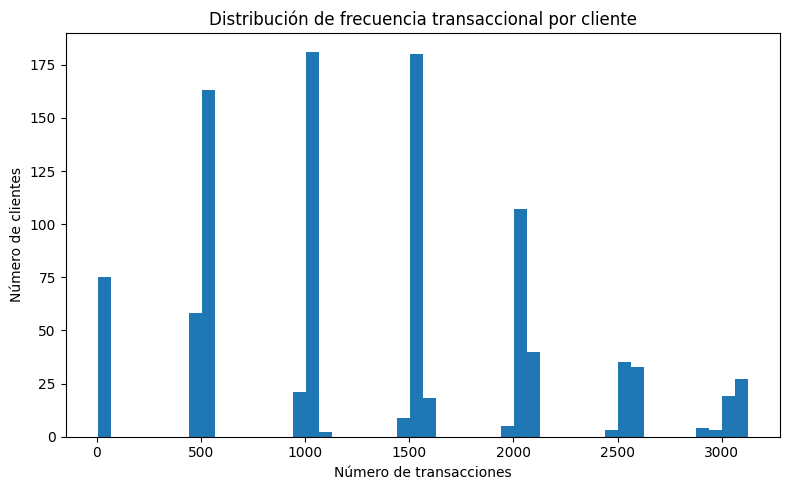

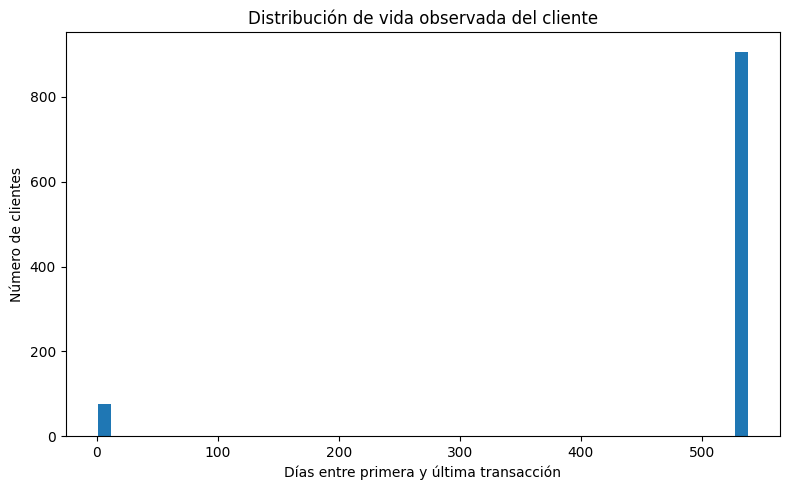

In [21]:
# Visualización de la frecuencia transaccional y vida observada para definir elegibilidad.
plt.figure(figsize=(8, 5))
plt.hist(client_features["frequency"], bins=50)
plt.title("Distribución de frecuencia transaccional por cliente")
plt.xlabel("Número de transacciones")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_frecuencia_cliente.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(client_features["customer_lifetime_days"], bins=50)
plt.title("Distribución de vida observada del cliente")
plt.xlabel("Días entre primera y última transacción")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribucion_vida_cliente.png", dpi=150)
plt.show()

In [22]:
# Evaluación de umbrales candidatos para definir clientes con historial suficiente.
thresholds = []

for min_txn in [5, 10, 20, 30, 50, 100]:
    for min_lifetime in [1, 7, 30, 60, 90]:
        eligible_mask_tmp = (
            (client_features["frequency"] >= min_txn) &
            (client_features["customer_lifetime_days"] >= min_lifetime)
        )

        thresholds.append({
            "min_transactions": min_txn,
            "min_lifetime_days": min_lifetime,
            "eligible_clients": int(eligible_mask_tmp.sum()),
            "excluded_clients": int((~eligible_mask_tmp).sum()),
            "eligible_pct": eligible_mask_tmp.mean() * 100
        })

eligibility_thresholds_df = pd.DataFrame(thresholds)
display(eligibility_thresholds_df)

eligibility_thresholds_df.to_csv(TABLES_DIR / "eligibility_thresholds.csv", index=False)

,min_transactions,min_lifetime_days,eligible_clients,excluded_clients,eligible_pct
0,5,1,983,0,100.0000
1,5,7,908,75,92.3703
2,5,30,908,75,92.3703
3,5,60,908,75,92.3703
4,5,90,908,75,92.3703
5,10,1,948,35,96.4395
6,10,7,908,75,92.3703
7,10,30,908,75,92.3703
8,10,60,908,75,92.3703
9,10,90,908,75,92.3703


## 10. Segmentación sobre clientes elegibles

In [23]:
# Definición de muestra analítica elegible para segmentación comportamental robusta.
MIN_TRANSACTIONS = 30
MIN_LIFETIME_DAYS = 30

eligible_mask = (
    (client_features["frequency"] >= MIN_TRANSACTIONS) &
    (client_features["customer_lifetime_days"] >= MIN_LIFETIME_DAYS)
)

client_features_eligible = client_features.loc[eligible_mask].copy()
client_features_low_history = client_features.loc[~eligible_mask].copy()

print("Clientes totales:", len(client_features))
print("Clientes elegibles:", len(client_features_eligible))
print("Clientes excluidos por historial insuficiente:", len(client_features_low_history))
print("Porcentaje elegible:", round(len(client_features_eligible) / len(client_features) * 100, 2))

display(client_features_low_history[[
    "cc_num",
    "frequency",
    "customer_lifetime_days",
    "recency_days",
    "monetary_total",
    "ticket_mean",
    "category_nunique",
    "merchant_nunique"
]].head(10))

Clientes totales: 983
Clientes elegibles: 908
Clientes excluidos por historial insuficiente: 75
Porcentaje elegible: 92.37


,cc_num,frequency,customer_lifetime_days,recency_days,monetary_total,ticket_mean,category_nunique,merchant_nunique
8,501818133297,8,2,57,"4,946.5400",618.3175,3,8
11,501851115094,15,2,454,"6,467.8100",431.1873,5,15
13,501894933032,7,2,343,"3,741.7500",534.5357,3,6
20,503886119844,9,2,6,"6,319.6300",702.1811,5,9
34,577891228931,12,2,499,"8,789.7400",732.4783,5,12
63,676179782773,11,2,266,"8,247.5300",749.7755,4,11
76,676327197445,8,2,245,"6,197.9500",774.7437,4,8
82,4076173495454,12,2,456,"7,807.2800",650.6067,5,12
105,4457486401506,10,2,214,"6,263.2100",626.3210,6,10
118,4593569795412,19,2,482,"8,431.9300",443.7858,7,18


In [24]:
# Comparación descriptiva entre clientes elegibles y clientes con historial insuficiente.
comparison_groups = client_features.copy()
comparison_groups["eligibility_group"] = np.where(
    eligible_mask,
    "elegible_para_segmentacion",
    "historial_insuficiente"
)

eligibility_profile = (
    comparison_groups
    .groupby("eligibility_group")[[
        "frequency",
        "customer_lifetime_days",
        "recency_days",
        "monetary_total",
        "ticket_mean",
        "category_nunique",
        "merchant_nunique",
        "top_category_share",
        "top3_category_share"
    ]]
    .mean()
)

display(eligibility_profile)
eligibility_profile.to_csv(TABLES_DIR / "eligibility_profile_comparison.csv")

,frequency,customer_lifetime_days,recency_days,monetary_total,ticket_mean,category_nunique,merchant_nunique,top_category_share,top3_category_share
eligibility_group,,,,,,,,,
elegible_para_segmentacion,"1,427.2401",536.9284,1.1619,"99,977.9821",70.9066,14.0000,526.8106,0.1773,0.4183
historial_insuficiente,9.8800,1.9867,276.6000,"5,898.9481",596.3274,5.0133,9.7067,0.5314,0.9341


In [25]:
# Selección de variables numéricas para el modelo de clientes elegibles.
X_eligible, model_features_eligible = select_model_features(client_features_eligible)

print("Clientes elegibles:", X_eligible.shape[0])
print("Variables candidatas:", X_eligible.shape[1])
display(X_eligible.head())

Clientes elegibles: 908
Variables candidatas: 18


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
0,1518,"85,043.4700",56.0234,36.6400,122.6326,1.0200,"3,075.0900",14,575,0.3261,1,537,0.3597,0.1489,0.1561,0.3353,0.1722,0.4558
1,1531,"105,640.2000",69.0008,52.4600,102.6820,1.0400,"1,290.3700",14,578,0.3370,1,535,0.2051,0.3063,0.2900,0.1986,0.1395,0.3481
2,510,"58,673.6300",115.0463,35.3000,"1,202.9880",1.0100,"27,119.7700",14,338,0.3353,3,535,0.2569,0.2176,0.2314,0.2941,0.4644,0.6450
3,528,"59,129.6100",111.9879,76.7050,143.3107,8.8600,"1,164.3600",14,358,0.3144,2,536,0.2614,0.2159,0.2765,0.2462,0.1814,0.4743
4,496,"25,160.1100",50.7260,35.6400,65.8440,1.0200,750.3900,14,346,0.3226,1,532,0.3327,0.1552,0.1673,0.3448,0.1601,0.4200


In [26]:
# Preprocesamiento selectivo aplicado a la muestra elegible.
X_eligible_processed, metadata_eligible = preprocess_feature_matrix(
    X_eligible,
    transform_method="log",
    skew_threshold=1.0,
    winsor_lower=0.01,
    winsor_upper=0.99,
    drop_zero_variance=True
)

display(metadata_eligible["skewness_before"])
display(metadata_eligible["skewness_after"])

print("Variables winsorizadas:", metadata_eligible["winsorized_columns"])
print("Variables transformadas:", metadata_eligible["transformed_columns"])
print("Variables eliminadas por varianza cero:", metadata_eligible["dropped_zero_variance_columns"])

metadata_eligible["skewness_before"].to_csv(TABLES_DIR / "asimetria_variables_cliente_elegible_antes.csv", index=False)
metadata_eligible["skewness_after"].to_csv(TABLES_DIR / "asimetria_variables_cliente_elegible_despues.csv", index=False)

,feature,skewness
0,ticket_std,6.2601
1,recency_days,4.1010
2,ticket_max,3.7680
3,weekend_txn_pct,1.5013
4,top_category_share,1.1922
5,monetary_total,0.9824
6,ticket_median,0.9700
7,ticket_mean,0.8088
8,frequency,0.4888
9,txn_pct_morning,0.0556


,feature,skewness
0,recency_days,4.1010
1,weekend_txn_pct,1.5013
2,ticket_std,1.2804
3,top_category_share,1.1922
4,ticket_median,0.9875
5,monetary_total,0.9633
6,ticket_mean,0.7929
7,ticket_max,0.7433
8,frequency,0.4876
9,txn_pct_morning,0.0556


Variables winsorizadas: ['frequency', 'monetary_total', 'ticket_mean', 'ticket_median', 'ticket_std', 'ticket_max', 'category_nunique', 'merchant_nunique']
Variables transformadas: ['ticket_std', 'ticket_max']
Variables eliminadas por varianza cero: ['category_nunique']


,component,explained_variance_ratio,cumulative_variance
0,1,0.3091,0.3091
1,2,0.1934,0.5024
2,3,0.1508,0.6533
3,4,0.0978,0.7510
4,5,0.0855,0.8365
5,6,0.0643,0.9008
6,7,0.0385,0.9393
7,8,0.0335,0.9728
8,9,0.0082,0.9810
9,10,0.0063,0.9873


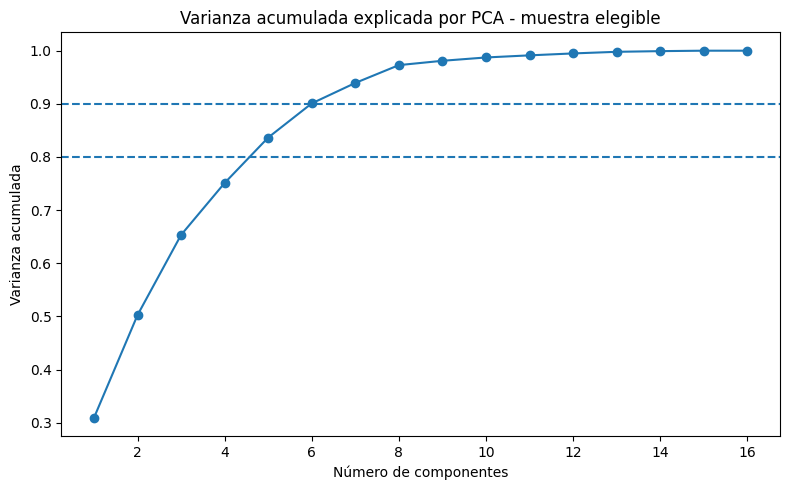

In [27]:
# Preprocesamiento selectivo aplicado a la muestra elegible.
X_eligible_scaled, scaler_eligible = scale_features(X_eligible_processed, scaler_type="robust")

pca_eligible = PCA(random_state=RANDOM_STATE)
pca_eligible.fit(X_eligible_scaled)

explained_eligible = pd.DataFrame({
    "component": np.arange(1, len(pca_eligible.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_eligible.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_eligible.explained_variance_ratio_)
})

display(explained_eligible)
explained_eligible.to_csv(TABLES_DIR / "pca_varianza_elegible.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(explained_eligible["component"], explained_eligible["cumulative_variance"], marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.title("Varianza acumulada explicada por PCA - muestra elegible")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_varianza_elegible.png", dpi=150)
plt.show()

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,k,model,inertia
0,3,0.2592,1.4679,252.4859,3,KMeans_Eligible,"1,039.5857"
1,4,0.2822,1.3493,246.4084,4,KMeans_Eligible,891.0324
2,5,0.2721,1.3712,219.9975,5,KMeans_Eligible,820.2779
3,6,0.2465,1.4449,206.9810,6,KMeans_Eligible,754.2588
4,7,0.2600,1.4302,203.0269,7,KMeans_Eligible,688.6253
5,8,0.2588,1.3611,196.1563,8,KMeans_Eligible,641.2792
6,9,0.2678,1.3496,186.8513,9,KMeans_Eligible,608.2640
7,10,0.2678,1.3407,183.1259,10,KMeans_Eligible,571.2383


,n_clusters,silhouette,davies_bouldin,calinski_harabasz,k,model
0,3,0.2294,1.5243,223.0872,3,Agglomerative_Eligible
1,4,0.2764,1.3731,240.5978,4,Agglomerative_Eligible
2,5,0.2562,1.3307,209.3305,5,Agglomerative_Eligible
3,6,0.2607,1.3475,190.0248,6,Agglomerative_Eligible
4,7,0.2734,1.3711,179.4748,7,Agglomerative_Eligible
5,8,0.2321,1.4890,173.1602,8,Agglomerative_Eligible
6,9,0.2387,1.3902,169.6307,9,Agglomerative_Eligible
7,10,0.2319,1.3896,165.5001,10,Agglomerative_Eligible


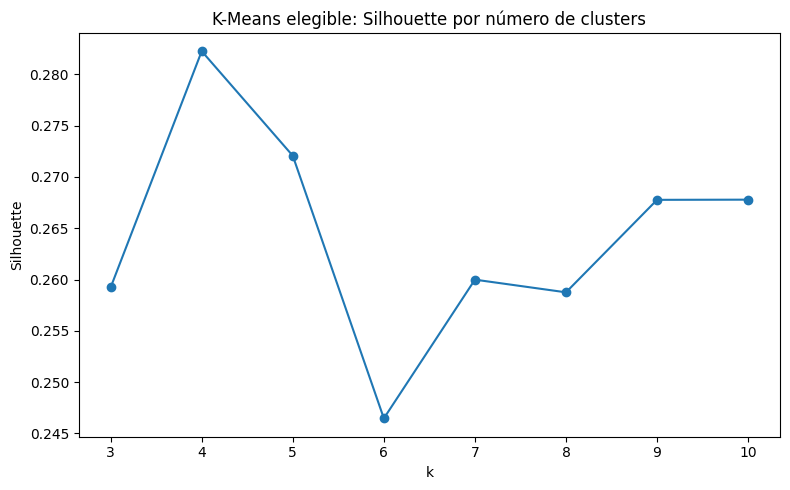

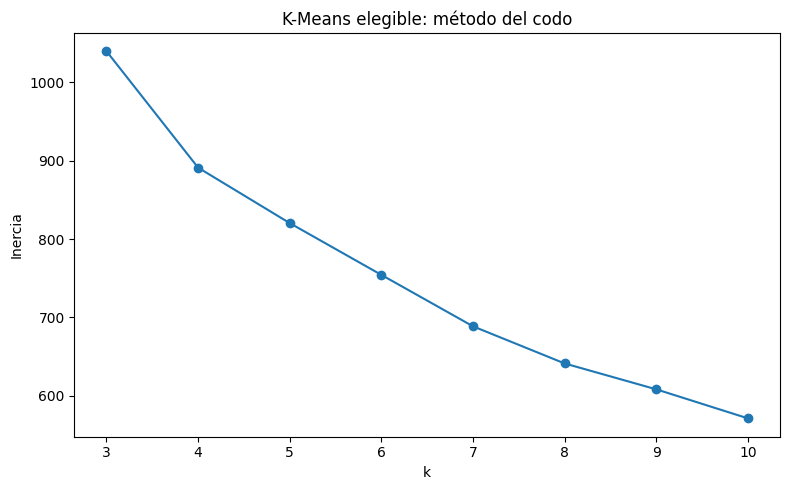

In [28]:
# Escalado robusto y PCA sobre la muestra elegible.
kmeans_eligible_df = run_kmeans_grid(X_eligible_scaled, range(3, 11), "KMeans_Eligible")
agg_eligible_df = run_agglomerative_grid(X_eligible_scaled, range(3, 11), "Agglomerative_Eligible")

display(kmeans_eligible_df)
display(agg_eligible_df)

kmeans_eligible_df.to_csv(TABLES_DIR / "evaluacion_kmeans_elegible.csv", index=False)
agg_eligible_df.to_csv(TABLES_DIR / "evaluacion_agglomerative_elegible.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eligible_df["k"], kmeans_eligible_df["silhouette"], marker="o")
plt.title("K-Means elegible: Silhouette por número de clusters")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elegible_silhouette_por_k.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kmeans_eligible_df["k"], kmeans_eligible_df["inertia"], marker="o")
plt.title("K-Means elegible: método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "kmeans_elegible_elbow.png", dpi=150)
plt.show()

In [29]:
# Evaluación opcional con HDBSCAN como enfoque basado en densidad.
try:
    import hdbscan

    hdbscan_eligible_rows = []
    for min_cluster_size in [10, 20, 30, 50, 75, 100]:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric="euclidean")
        labels = clusterer.fit_predict(X_eligible_scaled)
        noise_pct = np.mean(labels == -1) * 100
        valid_mask = labels != -1

        if valid_mask.sum() > 2 and len(np.unique(labels[valid_mask])) >= 2:
            metrics = evaluate_clustering(X_eligible_scaled.loc[valid_mask], labels[valid_mask])
        else:
            metrics = {
                "n_clusters": len(set(labels)) - (1 if -1 in labels else 0),
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan
            }

        metrics["model"] = "HDBSCAN_Eligible"
        metrics["min_cluster_size"] = min_cluster_size
        metrics["noise_pct"] = noise_pct
        hdbscan_eligible_rows.append(metrics)

    hdbscan_eligible_df = pd.DataFrame(hdbscan_eligible_rows)
    display(hdbscan_eligible_df)
    hdbscan_eligible_df.to_csv(TABLES_DIR / "evaluacion_hdbscan_elegible.csv", index=False)

except ImportError:
    print("hdbscan no está instalado. Si deseas ejecutar esta sección: pip install hdbscan")

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,model,min_cluster_size,noise_pct
0,6,0.3346,1.1247,208.4379,HDBSCAN_Eligible,10,19.1630
1,4,0.3695,0.9953,286.6892,HDBSCAN_Eligible,20,27.9736
2,4,0.3860,0.9518,294.0225,HDBSCAN_Eligible,30,32.1586
3,2,0.3468,1.3001,283.1214,HDBSCAN_Eligible,50,43.6123
4,2,0.4649,0.8627,366.9466,HDBSCAN_Eligible,75,60.6828
5,0,NaN,NaN,NaN,HDBSCAN_Eligible,100,100.0000


In [30]:
# Escalado robusto y PCA sobre la muestra elegible.
best_k_eligible = int(kmeans_eligible_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("k seleccionado en modelo elegible según Silhouette:", best_k_eligible)

stability_seed_eligible_df = stability_by_seed(X_eligible_scaled, best_k_eligible, seed_list)
bootstrap_stability_eligible_df = bootstrap_stability_kmeans(
    X_eligible_scaled,
    best_k_eligible,
    n_iterations=20,
    sample_frac=0.80
)

display(stability_seed_eligible_df)
display(bootstrap_stability_eligible_df.describe())

stability_seed_eligible_df.to_csv(TABLES_DIR / "estabilidad_kmeans_semillas_elegible.csv", index=False)
bootstrap_stability_eligible_df.to_csv(TABLES_DIR / "estabilidad_kmeans_bootstrap_elegible.csv", index=False)

k seleccionado en modelo elegible según Silhouette: 4


,seed_a,seed_b,ari
0,1,7,1.0000
1,1,21,1.0000
2,1,42,1.0000
3,1,99,1.0000
4,1,123,1.0000
5,7,21,1.0000
6,7,42,1.0000
7,7,99,1.0000
8,7,123,1.0000
9,21,42,1.0000


,iteration,sample_size,ari_vs_reference
count,20.0000,20.0000,20.0000
mean,10.5000,726.0000,0.9897
std,5.9161,0.0000,0.0106
min,1.0000,726.0000,0.9525
25%,5.7500,726.0000,0.9873
50%,10.5000,726.0000,0.9919
75%,15.2500,726.0000,0.9967
max,20.0000,726.0000,1.0000


In [31]:
# Escalado robusto y PCA sobre la muestra elegible.
final_eligible_model = KMeans(n_clusters=best_k_eligible, random_state=RANDOM_STATE, n_init=20)
labels_eligible = final_eligible_model.fit_predict(X_eligible_scaled)

client_segments_eligible, segment_sizes_eligible, segment_profile_eligible, segment_profile_index_eligible = build_segment_profiles(
    client_features_eligible,
    X_eligible,
    labels_eligible
)

dominant_vars_eligible_df = get_dominant_variables(segment_profile_index_eligible)

display(segment_sizes_eligible)
display(segment_profile_eligible)
display(segment_profile_index_eligible)
display(dominant_vars_eligible_df)

client_segments_eligible.to_csv(TABLES_DIR / "clientes_segmentados_elegible.csv", index=False)
segment_sizes_eligible.to_csv(TABLES_DIR / "segment_sizes_elegible.csv")
segment_profile_eligible.to_csv(TABLES_DIR / "perfil_segmentos_promedio_elegible.csv")
segment_profile_index_eligible.to_csv(TABLES_DIR / "perfil_segmentos_indice_vs_promedio_elegible.csv")
dominant_vars_eligible_df.to_csv(TABLES_DIR / "variables_dominantes_por_segmento_elegible.csv", index=False)

,n_clients,pct_clients
segment_id,,
0,254,27.9736
1,361,39.7577
2,192,21.1454
3,101,11.1233


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,"1,867.7323","110,612.3751",59.7021,35.4041,153.1861,1.0127,"3,892.8545",14.0000,590.3740,0.3478,1.0236,537.1811,0.3582,0.1411,0.1396,0.3612,0.1537,0.3920
1,"1,223.5651","80,271.0507",66.3691,43.7144,139.9285,1.0955,"2,956.2117",14.0000,507.5900,0.3492,1.0139,537.2355,0.2266,0.2708,0.2707,0.2319,0.1762,0.4121
2,"1,657.5573","151,797.3631",92.4175,63.4091,121.7985,6.4474,"1,920.2335",14.0000,557.3490,0.3435,1.0156,537.2552,0.3173,0.1810,0.1796,0.3221,0.2060,0.4576
3,609.6238,"45,163.5790",74.4105,47.1572,150.8901,2.8614,"2,150.9944",14.0000,377.6040,0.3471,2.3168,534.5743,0.2737,0.2231,0.2179,0.2853,0.1858,0.4319


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,1.3086,1.1064,0.8420,0.7707,1.0863,0.4219,1.3379,1.0000,1.1207,1.0012,0.8810,1.0005,1.2444,0.6712,0.6682,1.2323,0.8673,0.9372
1,0.8573,0.8029,0.9360,0.9516,0.9922,0.4564,1.0160,1.0000,0.9635,1.0053,0.8726,1.0006,0.7873,1.2882,1.2960,0.7912,0.9938,0.9851
2,1.1614,1.5183,1.3034,1.3803,0.8637,2.6859,0.6600,1.0000,1.0580,0.9888,0.8741,1.0006,1.1024,0.8609,0.8597,1.0991,1.1618,1.0939
3,0.4271,0.4517,1.0494,1.0266,1.0700,1.1920,0.7393,1.0000,0.7168,0.9993,1.9940,0.9956,0.9510,1.0611,1.0430,0.9736,1.0482,1.0326


,segment_id,direction,feature,index_vs_average
0,0,above_average,ticket_max,1.3379
1,0,above_average,frequency,1.3086
2,0,above_average,txn_pct_afternoon,1.2444
3,0,above_average,txn_pct_night,1.2323
4,0,above_average,merchant_nunique,1.1207
5,0,above_average,monetary_total,1.1064
6,0,above_average,ticket_std,1.0863
7,0,above_average,weekend_txn_pct,1.0012
8,0,below_average,ticket_min,0.4219
9,0,below_average,txn_pct_morning,0.6682


## 11. Comparación entre modelo general y modelo elegible

In [32]:
# Evaluación del modelo general con K-Means y clustering jerárquico para distintos valores de k.
model_comparison_summary = pd.DataFrame([
    {
        "model": "KMeans_all_clients",
        "sample_size": len(client_segments_all),
        "selected_k": best_k_all,
        "silhouette": kmeans_all_df.loc[kmeans_all_df["k"] == best_k_all, "silhouette"].iloc[0],
        "davies_bouldin": kmeans_all_df.loc[kmeans_all_df["k"] == best_k_all, "davies_bouldin"].iloc[0],
        "calinski_harabasz": kmeans_all_df.loc[kmeans_all_df["k"] == best_k_all, "calinski_harabasz"].iloc[0],
        "mean_ari_seed": stability_seed_all_df["ari"].mean(),
        "mean_ari_bootstrap": bootstrap_stability_all_df["ari_vs_reference"].mean(),
        "largest_segment_pct": segment_sizes_all["pct_clients"].max()
    },
    {
        "model": "KMeans_eligible_clients",
        "sample_size": len(client_segments_eligible),
        "selected_k": best_k_eligible,
        "silhouette": kmeans_eligible_df.loc[kmeans_eligible_df["k"] == best_k_eligible, "silhouette"].iloc[0],
        "davies_bouldin": kmeans_eligible_df.loc[kmeans_eligible_df["k"] == best_k_eligible, "davies_bouldin"].iloc[0],
        "calinski_harabasz": kmeans_eligible_df.loc[kmeans_eligible_df["k"] == best_k_eligible, "calinski_harabasz"].iloc[0],
        "mean_ari_seed": stability_seed_eligible_df["ari"].mean(),
        "mean_ari_bootstrap": bootstrap_stability_eligible_df["ari_vs_reference"].mean(),
        "largest_segment_pct": segment_sizes_eligible["pct_clients"].max()
    }
])

display(model_comparison_summary)
model_comparison_summary.to_csv(TABLES_DIR / "comparacion_modelo_general_vs_elegible.csv", index=False)

,model,sample_size,selected_k,silhouette,davies_bouldin,calinski_harabasz,mean_ari_seed,mean_ari_bootstrap,largest_segment_pct
0,KMeans_all_clients,983,3,0.7463,0.5917,854.2118,1.0000,0.9997,92.4720
1,KMeans_eligible_clients,908,4,0.2822,1.3493,246.4084,1.0000,0.9897,39.7577


## 12. Plantillas de interpretación y KPIs

## 13. Exportación de artefactos generados

In [33]:
# Inventario de artefactos exportados por el notebook.
artifacts = sorted(TABLES_DIR.glob("*.csv")) + sorted(FIGURES_DIR.glob("*.png"))

print("Artefactos generados:")
for artifact in artifacts:
    print("-", artifact.relative_to(PROJECT_DIR))

Artefactos generados:
- outputs/tables/asimetria_variables_cliente_elegible_antes.csv
- outputs/tables/asimetria_variables_cliente_elegible_despues.csv
- outputs/tables/asimetria_variables_cliente_general_antes.csv
- outputs/tables/asimetria_variables_cliente_general_despues.csv
- outputs/tables/auditoria_inicial_columnas.csv
- outputs/tables/clientes_segmentados_elegible.csv
- outputs/tables/clientes_segmentados_general.csv
- outputs/tables/comparacion_modelo_general_vs_elegible.csv
- outputs/tables/eligibility_profile_comparison.csv
- outputs/tables/eligibility_summary.csv
- outputs/tables/eligibility_thresholds.csv
- outputs/tables/estabilidad_kmeans_bootstrap_elegible.csv
- outputs/tables/estabilidad_kmeans_bootstrap_general.csv
- outputs/tables/estabilidad_kmeans_semillas_elegible.csv
- outputs/tables/estabilidad_kmeans_semillas_general.csv
- outputs/tables/evaluacion_agglomerative_elegible.csv
- outputs/tables/evaluacion_agglomerative_general.csv
- outputs/tables/evaluacion_hdbsc

## 14. Insumos para el Capítulo 5

Los principales artefactos generados para el análisis de resultados son:

- `auditoria_inicial_columnas.csv`
- `resumen_categorias.csv`
- `matriz_cliente_features.csv`
- `asimetria_variables_cliente_general_antes.csv`
- `asimetria_variables_cliente_general_despues.csv`
- `asimetria_variables_cliente_elegible_antes.csv`
- `asimetria_variables_cliente_elegible_despues.csv`
- `evaluacion_kmeans_general.csv`
- `evaluacion_kmeans_elegible.csv`
- `comparacion_modelo_general_vs_elegible.csv`
- `segment_sizes_general.csv`
- `segment_sizes_elegible.csv`
- `perfil_segmentos_indice_vs_promedio_general.csv`
- `perfil_segmentos_indice_vs_promedio_elegible.csv`
- `variables_dominantes_por_segmento_general.csv`
- `variables_dominantes_por_segmento_elegible.csv`

La comparación entre modelo general y modelo elegible se fundamenta en calidad interna, estabilidad, balance de segmentos, interpretabilidad y utilidad comercial.

## 15. Comparación interpretativa k=3 vs. k=4 en muestra elegible

La selección del número de clusters no debe depender únicamente de una métrica interna.  
Aunque el modelo elegible con k=3 puede ofrecer la mejor métrica de Silhouette, se evalúa también k=4 como alternativa de negocio para determinar si permite dividir el segmento mayoritario y generar perfiles más accionables.

Criterios de comparación:

1. Calidad interna: Silhouette, Davies-Bouldin y Calinski-Harabasz.
2. Estabilidad: ARI con semillas y remuestreo.
3. Balance de segmentos: porcentaje del segmento mayoritario.
4. Interpretabilidad: variables dominantes por segmento.
5. Accionabilidad: capacidad de traducir segmentos a objetivos, acciones y KPIs.

In [34]:
# Comparación explícita de soluciones k=3 y k=4 sobre muestra elegible

candidate_k_values = [3, 4]
candidate_solution_rows = []
candidate_segment_outputs = {}

for candidate_k in candidate_k_values:
    model = KMeans(
        n_clusters=candidate_k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(X_eligible_scaled)

    metrics = evaluate_clustering(X_eligible_scaled, labels)
    metrics["k"] = candidate_k
    metrics["model"] = f"KMeans_Eligible_k{candidate_k}"
    metrics["inertia"] = model.inertia_

    client_segments_candidate, segment_sizes_candidate, segment_profile_candidate, segment_profile_index_candidate = build_segment_profiles(
        client_features_eligible,
        X_eligible,
        labels
    )

    dominant_vars_candidate = get_dominant_variables(segment_profile_index_candidate)

    stability_seed_candidate = stability_by_seed(
        X_eligible_scaled,
        candidate_k,
        seed_list
    )

    bootstrap_stability_candidate = bootstrap_stability_kmeans(
        X_eligible_scaled,
        candidate_k,
        n_iterations=20,
        sample_frac=0.80
    )

    metrics["mean_ari_seed"] = stability_seed_candidate["ari"].mean()
    metrics["mean_ari_bootstrap"] = bootstrap_stability_candidate["ari_vs_reference"].mean()
    metrics["largest_segment_pct"] = segment_sizes_candidate["pct_clients"].max()
    metrics["smallest_segment_pct"] = segment_sizes_candidate["pct_clients"].min()

    candidate_solution_rows.append(metrics)

    candidate_segment_outputs[candidate_k] = {
        "model": model,
        "labels": labels,
        "client_segments": client_segments_candidate,
        "segment_sizes": segment_sizes_candidate,
        "segment_profile": segment_profile_candidate,
        "segment_profile_index": segment_profile_index_candidate,
        "dominant_vars": dominant_vars_candidate,
        "stability_seed": stability_seed_candidate,
        "bootstrap_stability": bootstrap_stability_candidate
    }

candidate_solution_comparison = pd.DataFrame(candidate_solution_rows)

display(candidate_solution_comparison)

candidate_solution_comparison.to_csv(
    TABLES_DIR / "comparacion_k3_k4_muestra_elegible.csv",
    index=False
)

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,k,model,inertia,mean_ari_seed,mean_ari_bootstrap,largest_segment_pct,smallest_segment_pct
0,3,0.2592,1.4679,252.4859,3,KMeans_Eligible_k3,"1,039.5857",0.9973,0.9852,48.7885,11.0132
1,4,0.2822,1.3493,246.4084,4,KMeans_Eligible_k4,891.0324,1.0000,0.9897,39.7577,11.1233


In [35]:
# Tamaños de segmentos para k=3 y k=4

for candidate_k in candidate_k_values:
    print(f"\nSegmentos para k={candidate_k}")
    display(candidate_segment_outputs[candidate_k]["segment_sizes"])

    candidate_segment_outputs[candidate_k]["segment_sizes"].to_csv(
        TABLES_DIR / f"segment_sizes_elegible_k{candidate_k}.csv"
    )


Segmentos para k=3


,n_clients,pct_clients
segment_id,,
0,365,40.1982
1,443,48.7885
2,100,11.0132



Segmentos para k=4


,n_clients,pct_clients
segment_id,,
0,254,27.9736
1,361,39.7577
2,192,21.1454
3,101,11.1233


In [36]:
# Perfil índice vs promedio para k=3 y k=4

for candidate_k in candidate_k_values:
    print(f"\nPerfil índice vs promedio para k={candidate_k}")
    display(candidate_segment_outputs[candidate_k]["segment_profile_index"])

    candidate_segment_outputs[candidate_k]["segment_profile"].to_csv(
        TABLES_DIR / f"perfil_segmentos_promedio_elegible_k{candidate_k}.csv"
    )

    candidate_segment_outputs[candidate_k]["segment_profile_index"].to_csv(
        TABLES_DIR / f"perfil_segmentos_indice_vs_promedio_elegible_k{candidate_k}.csv"
    )

    candidate_segment_outputs[candidate_k]["dominant_vars"].to_csv(
        TABLES_DIR / f"variables_dominantes_por_segmento_elegible_k{candidate_k}.csv",
        index=False
    )


Perfil índice vs promedio para k=3


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,1.3113,1.2760,0.9641,0.8895,1.0643,0.4226,1.2240,1.0000,1.1137,1.0076,0.8842,1.0005,1.2356,0.6826,0.6781,1.2257,0.9761,0.9923
1,0.8718,0.8948,1.0178,1.0832,0.9360,1.4307,0.8807,1.0000,0.9694,0.9945,0.8684,1.0005,0.8190,1.2446,1.2518,0.8228,1.0102,0.9998
2,0.4318,0.4587,1.0522,1.0346,1.0488,1.1997,0.7110,1.0000,0.7206,0.9965,2.0053,0.9956,0.9418,1.0749,1.0594,0.9611,1.0423,1.0289



Perfil índice vs promedio para k=4


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,1.3086,1.1064,0.8420,0.7707,1.0863,0.4219,1.3379,1.0000,1.1207,1.0012,0.8810,1.0005,1.2444,0.6712,0.6682,1.2323,0.8673,0.9372
1,0.8573,0.8029,0.9360,0.9516,0.9922,0.4564,1.0160,1.0000,0.9635,1.0053,0.8726,1.0006,0.7873,1.2882,1.2960,0.7912,0.9938,0.9851
2,1.1614,1.5183,1.3034,1.3803,0.8637,2.6859,0.6600,1.0000,1.0580,0.9888,0.8741,1.0006,1.1024,0.8609,0.8597,1.0991,1.1618,1.0939
3,0.4271,0.4517,1.0494,1.0266,1.0700,1.1920,0.7393,1.0000,0.7168,0.9993,1.9940,0.9956,0.9510,1.0611,1.0430,0.9736,1.0482,1.0326


,segment_id,n_clients,pct_clients,k
0,0,365,40.1982,3
1,1,443,48.7885,3
2,2,100,11.0132,3
3,0,254,27.9736,4
4,1,361,39.7577,4
5,2,192,21.1454,4
6,3,101,11.1233,4


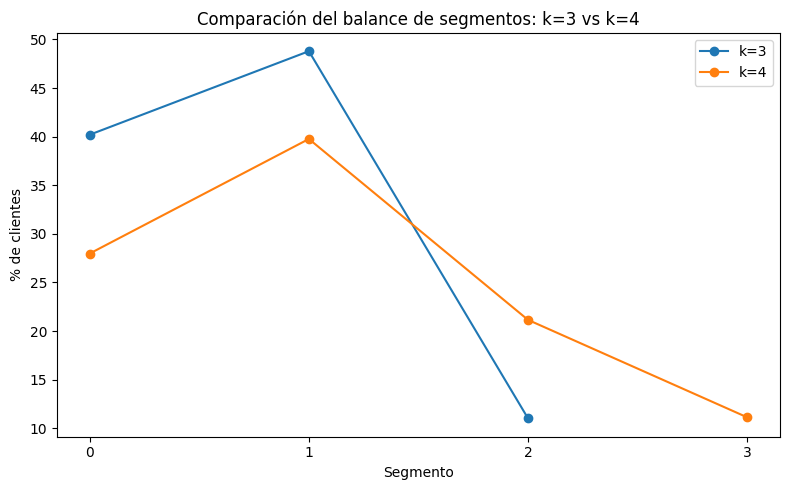

In [37]:
# Visualización comparativa del balance de segmentos

balance_plot_data = []

for candidate_k in candidate_k_values:
    sizes = candidate_segment_outputs[candidate_k]["segment_sizes"].reset_index()
    sizes["k"] = candidate_k
    balance_plot_data.append(sizes)

balance_plot_df = pd.concat(balance_plot_data, ignore_index=True)

display(balance_plot_df)

plt.figure(figsize=(8, 5))

for candidate_k in candidate_k_values:
    subset = balance_plot_df[balance_plot_df["k"] == candidate_k]
    plt.plot(
        subset["segment_id"].astype(str),
        subset["pct_clients"],
        marker="o",
        label=f"k={candidate_k}"
    )

plt.title("Comparación del balance de segmentos: k=3 vs k=4")
plt.xlabel("Segmento")
plt.ylabel("% de clientes")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "balance_segmentos_k3_vs_k4.png", dpi=150)
plt.show()

## 16. Regla de decisión para seleccionar la solución final

La selección de la solución final se realiza mediante un criterio multicriterio.  
No se elige automáticamente el mayor Silhouette, sino la configuración que mejor equilibra calidad interna, estabilidad, balance, interpretabilidad y utilidad comercial.

La solución final puede ser:

- **k=3**, si mantiene mejor calidad interna y estabilidad, y sus segmentos son suficientemente interpretables.
- **k=4**, si reduce el peso del segmento mayoritario y produce arquetipos de negocio más útiles, aunque su Silhouette sea ligeramente menor.

In [38]:
# Matriz de decisión cualitativa-cuantitativa

decision_matrix = candidate_solution_comparison.copy()

# Normalizaciones simples para facilitar comparación (mayor es mejor)
decision_matrix["silhouette_rank"] = decision_matrix["silhouette"].rank(ascending=False)
decision_matrix["davies_bouldin_rank"] = decision_matrix["davies_bouldin"].rank(ascending=True)
decision_matrix["largest_segment_rank"] = decision_matrix["largest_segment_pct"].rank(ascending=True)
decision_matrix["ari_seed_rank"] = decision_matrix["mean_ari_seed"].rank(ascending=False)
decision_matrix["ari_bootstrap_rank"] = decision_matrix["mean_ari_bootstrap"].rank(ascending=False)

# Score simple: menor ranking agregado = mejor balance general
rank_cols = [
    "silhouette_rank",
    "davies_bouldin_rank",
    "largest_segment_rank",
    "ari_seed_rank",
    "ari_bootstrap_rank"
]

decision_matrix["aggregate_rank_score"] = decision_matrix[rank_cols].sum(axis=1)

display(decision_matrix.sort_values("aggregate_rank_score"))

decision_matrix.to_csv(TABLES_DIR / "decision_matrix_k3_vs_k4.csv", index=False)

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,k,model,inertia,mean_ari_seed,mean_ari_bootstrap,largest_segment_pct,smallest_segment_pct,silhouette_rank,davies_bouldin_rank,largest_segment_rank,ari_seed_rank,ari_bootstrap_rank,aggregate_rank_score
1,4,0.2822,1.3493,246.4084,4,KMeans_Eligible_k4,891.0324,1.0000,0.9897,39.7577,11.1233,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000
0,3,0.2592,1.4679,252.4859,3,KMeans_Eligible_k3,"1,039.5857",0.9973,0.9852,48.7885,11.0132,2.0000,2.0000,2.0000,2.0000,2.0000,10.0000


In [39]:
# Selección recomendada por score agregado
recommended_k = int(
    decision_matrix
    .sort_values("aggregate_rank_score")
    .iloc[0]["k"]
)

print("k recomendado por matriz de decisión:", recommended_k)

final_selected_outputs = candidate_segment_outputs[recommended_k]

client_segments_final = final_selected_outputs["client_segments"].copy()
segment_sizes_final = final_selected_outputs["segment_sizes"].copy()
segment_profile_final = final_selected_outputs["segment_profile"].copy()
segment_profile_index_final = final_selected_outputs["segment_profile_index"].copy()
dominant_vars_final_df = final_selected_outputs["dominant_vars"].copy()

display(segment_sizes_final)
display(segment_profile_index_final)
display(dominant_vars_final_df)

client_segments_final.to_csv(TABLES_DIR / "clientes_segmentados_final.csv", index=False)
segment_sizes_final.to_csv(TABLES_DIR / "segment_sizes_final.csv")
segment_profile_final.to_csv(TABLES_DIR / "perfil_segmentos_promedio_final.csv")
segment_profile_index_final.to_csv(TABLES_DIR / "perfil_segmentos_indice_vs_promedio_final.csv")
dominant_vars_final_df.to_csv(TABLES_DIR / "variables_dominantes_por_segmento_final.csv", index=False)

k recomendado por matriz de decisión: 4


,n_clients,pct_clients
segment_id,,
0,254,27.9736
1,361,39.7577
2,192,21.1454
3,101,11.1233


,frequency,monetary_total,ticket_mean,ticket_median,ticket_std,ticket_min,ticket_max,category_nunique,merchant_nunique,weekend_txn_pct,recency_days,customer_lifetime_days,txn_pct_afternoon,txn_pct_early_morning,txn_pct_morning,txn_pct_night,top_category_share,top3_category_share
segment_id,,,,,,,,,,,,,,,,,,
0,1.3086,1.1064,0.8420,0.7707,1.0863,0.4219,1.3379,1.0000,1.1207,1.0012,0.8810,1.0005,1.2444,0.6712,0.6682,1.2323,0.8673,0.9372
1,0.8573,0.8029,0.9360,0.9516,0.9922,0.4564,1.0160,1.0000,0.9635,1.0053,0.8726,1.0006,0.7873,1.2882,1.2960,0.7912,0.9938,0.9851
2,1.1614,1.5183,1.3034,1.3803,0.8637,2.6859,0.6600,1.0000,1.0580,0.9888,0.8741,1.0006,1.1024,0.8609,0.8597,1.0991,1.1618,1.0939
3,0.4271,0.4517,1.0494,1.0266,1.0700,1.1920,0.7393,1.0000,0.7168,0.9993,1.9940,0.9956,0.9510,1.0611,1.0430,0.9736,1.0482,1.0326


,segment_id,direction,feature,index_vs_average
0,0,above_average,ticket_max,1.3379
1,0,above_average,frequency,1.3086
2,0,above_average,txn_pct_afternoon,1.2444
3,0,above_average,txn_pct_night,1.2323
4,0,above_average,merchant_nunique,1.1207
5,0,above_average,monetary_total,1.1064
6,0,above_average,ticket_std,1.0863
7,0,above_average,weekend_txn_pct,1.0012
8,0,below_average,ticket_min,0.4219
9,0,below_average,txn_pct_morning,0.6682


## 17. Resumen ejecutivo de resultados

Esta sección consolida las cifras principales que se utilizarán como base para el Capítulo 5.

In [40]:
# Selección del k del modelo general según Silhouette y evaluación de estabilidad mediante ARI.
summary_results = {
    "total_transactions": int(len(df)),
    "total_clients": int(client_features.shape[0]),
    "eligible_clients": int(client_features_eligible.shape[0]),
    "low_history_clients": int(client_features_low_history.shape[0]),
    "eligible_pct": float(client_features_eligible.shape[0] / client_features.shape[0] * 100),
    "selected_k_general": int(best_k_all),
    "selected_k_eligible_metric": int(best_k_eligible),
    "selected_k_final": int(recommended_k),
    "general_largest_segment_pct": float(segment_sizes_all["pct_clients"].max()),
    "eligible_largest_segment_pct": float(segment_sizes_eligible["pct_clients"].max()),
    "final_largest_segment_pct": float(segment_sizes_final["pct_clients"].max()),
    "final_solution_silhouette": float(
        candidate_solution_comparison.loc[candidate_solution_comparison["k"] == recommended_k, "silhouette"].iloc[0]
    ),
    "final_solution_davies_bouldin": float(
        candidate_solution_comparison.loc[candidate_solution_comparison["k"] == recommended_k, "davies_bouldin"].iloc[0]
    ),
    "final_solution_mean_ari_seed": float(
        candidate_solution_comparison.loc[candidate_solution_comparison["k"] == recommended_k, "mean_ari_seed"].iloc[0]
    ),
    "final_solution_mean_ari_bootstrap": float(
        candidate_solution_comparison.loc[candidate_solution_comparison["k"] == recommended_k, "mean_ari_bootstrap"].iloc[0]
    )
}

summary_results_df = pd.DataFrame([summary_results])
display(summary_results_df)

summary_results_df.to_csv(TABLES_DIR / "summary_results_for_chapter_5.csv", index=False)

,total_transactions,total_clients,eligible_clients,low_history_clients,eligible_pct,selected_k_general,selected_k_eligible_metric,selected_k_final,general_largest_segment_pct,eligible_largest_segment_pct,final_largest_segment_pct,final_solution_silhouette,final_solution_davies_bouldin,final_solution_mean_ari_seed,final_solution_mean_ari_bootstrap
0,1296675,983,908,75,92.3703,3,4,4,92.4720,39.7577,39.7577,0.2822,1.3493,1.0000,0.9897


## 18. Exportación de artefactos generados

Al ejecutar el notebook completo, los archivos generados en `outputs/tables` y `outputs/figures` deberán usarse para redactar el Capítulo 5.

In [41]:
# Inventario de artefactos exportados por el notebook.
artifacts = sorted(TABLES_DIR.glob("*.csv")) + sorted(FIGURES_DIR.glob("*.png"))

print("Artefactos generados:")
for artifact in artifacts:
    print("-", artifact.relative_to(PROJECT_DIR))

Artefactos generados:
- outputs/tables/asimetria_variables_cliente_elegible_antes.csv
- outputs/tables/asimetria_variables_cliente_elegible_despues.csv
- outputs/tables/asimetria_variables_cliente_general_antes.csv
- outputs/tables/asimetria_variables_cliente_general_despues.csv
- outputs/tables/auditoria_inicial_columnas.csv
- outputs/tables/clientes_segmentados_elegible.csv
- outputs/tables/clientes_segmentados_final.csv
- outputs/tables/clientes_segmentados_general.csv
- outputs/tables/comparacion_k3_k4_muestra_elegible.csv
- outputs/tables/comparacion_modelo_general_vs_elegible.csv
- outputs/tables/decision_matrix_k3_vs_k4.csv
- outputs/tables/eligibility_profile_comparison.csv
- outputs/tables/eligibility_summary.csv
- outputs/tables/eligibility_thresholds.csv
- outputs/tables/estabilidad_kmeans_bootstrap_elegible.csv
- outputs/tables/estabilidad_kmeans_bootstrap_general.csv
- outputs/tables/estabilidad_kmeans_semillas_elegible.csv
- outputs/tables/estabilidad_kmeans_semillas_gene

## 19. Playbook final de marketing por segmento

En esta sección se define manualmente un playbook final a partir del perfil estadístico de los segmentos seleccionados, considerando:

- tamaño relativo del segmento;
- frecuencia transaccional;
- gasto total;
- ticket promedio y mediano;
- diversidad de comercios;
- concentración del gasto;
- recencia;
- patrón temporal de consumo;
- utilidad comercial del segmento.

La solución final recomendada corresponde a la segmentación de clientes elegibles con **K-Means y k=4**.

In [42]:
# Playbook final definido con criterio de negocio a partir del perfil estadístico.
# La denominación se mantiene trazable: cada denominación se justifica con variables dominantes del perfil.

segment_name_map = {
    0: "Clientes recurrentes diversificados de alto uso",
    1: "Clientes de consumo moderado matutino",
    2: "Clientes de alto valor transaccional",
    3: "Clientes elegibles de baja actividad"
}

segment_business_map = {
    0: {
        "dominant_pattern": (
            "Alta frecuencia transaccional, gasto total superior al promedio, "
            "alta diversidad de comercios y mayor presencia relativa en consumos de tarde/noche."
        ),
        "business_objective": "Fidelización, mantenimiento de recurrencia y personalización por hábitos de uso",
        "recommended_action": (
            "Diseñar campañas de beneficios recurrentes, promociones por categorías frecuentes "
            "y comunicaciones personalizadas para sostener uso y evitar migración de gasto."
        ),
        "suggested_kpi": (
            "Frecuencia mensual; gasto incremental; retención de uso; número de comercios activos"
        )
    },
    1: {
        "dominant_pattern": (
            "Segmento de mayor tamaño, con gasto y frecuencia por debajo del promedio elegible, "
            "ticket moderado y mayor peso relativo de consumos en mañana/madrugada."
        ),
        "business_objective": "Activación de mayor uso y aumento gradual de valor transaccional",
        "recommended_action": (
            "Aplicar campañas de activación ligera, incentivos por recurrencia y ofertas de bajo riesgo "
            "para incrementar frecuencia y gasto sin saturar al cliente."
        ),
        "suggested_kpi": (
            "Incremento de frecuencia mensual; uplift de gasto; tasa de respuesta; gasto promedio por cliente"
        )
    },
    2: {
        "dominant_pattern": (
            "Mayor gasto total, ticket promedio y ticket mediano superiores al promedio, "
            "con concentración de consumo moderadamente más alta."
        ),
        "business_objective": "Fidelización de alto valor, retención y venta cruzada selectiva",
        "recommended_action": (
            "Ofrecer beneficios preferenciales, programas de lealtad, campañas premium y propuestas "
            "de venta cruzada basadas en categorías de alto consumo."
        ),
        "suggested_kpi": (
            "Gasto promedio mensual; retención de clientes de alto valor; Cross-sell Index; margen estimado"
        )
    },
    3: {
        "dominant_pattern": (
            "Menor frecuencia, menor gasto total, menor diversidad de comercios y recencia superior al promedio, "
            "aunque cumple criterios mínimos de elegibilidad."
        ),
        "business_objective": "Reactivación y prevención de caída de uso",
        "recommended_action": (
            "Implementar campañas de reactivación, recordatorios de beneficios, incentivos temporales "
            "y ofertas orientadas a recuperar frecuencia de uso."
        ),
        "suggested_kpi": (
            "Tasa de reactivación; reducción de recencia; número de transacciones posteriores a campaña; "
            "recuperación de gasto mensual"
        )
    }
}

playbook_final_rows = []

for segment_id in sorted(segment_sizes_final.index):
    business_info = segment_business_map.get(segment_id, {})
    playbook_final_rows.append({
        "segment_id": segment_id,
        "segment_name": segment_name_map.get(segment_id, "Segmento sin denominación"),
        "n_clients": int(segment_sizes_final.loc[segment_id, "n_clients"]),
        "pct_clients": float(segment_sizes_final.loc[segment_id, "pct_clients"]),
        "dominant_pattern": business_info.get("dominant_pattern", ""),
        "business_objective": business_info.get("business_objective", ""),
        "recommended_action": business_info.get("recommended_action", ""),
        "suggested_kpi": business_info.get("suggested_kpi", "")
    })

playbook_final_df = pd.DataFrame(playbook_final_rows)

display(playbook_final_df)

playbook_final_df.to_csv(TABLES_DIR / "playbook_segmentos_final.csv", index=False)

,segment_id,segment_name,n_clients,pct_clients,dominant_pattern,business_objective,recommended_action,suggested_kpi
0,0,Clientes recurrentes diversificados de alto uso,254,27.9736,"Alta frecuencia transaccional, gasto total sup...","Fidelización, mantenimiento de recurrencia y p...","Diseñar campañas de beneficios recurrentes, pr...",Frecuencia mensual; gasto incremental; retenci...
1,1,Clientes de consumo moderado matutino,361,39.7577,"Segmento de mayor tamaño, con gasto y frecuenc...",Activación de mayor uso y aumento gradual de v...,"Aplicar campañas de activación ligera, incenti...",Incremento de frecuencia mensual; uplift de ga...
2,2,Clientes de alto valor transaccional,192,21.1454,"Mayor gasto total, ticket promedio y ticket me...","Fidelización de alto valor, retención y venta ...","Ofrecer beneficios preferenciales, programas d...",Gasto promedio mensual; retención de clientes ...
3,3,Clientes elegibles de baja actividad,101,11.1233,"Menor frecuencia, menor gasto total, menor div...",Reactivación y prevención de caída de uso,"Implementar campañas de reactivación, recordat...",Tasa de reactivación; reducción de recencia; n...


In [43]:
# Incorporación de nombres de segmentos a la base final segmentada.

client_segments_final_named = client_segments_final.copy()
client_segments_final_named["segment_name"] = client_segments_final_named["segment_id"].map(segment_name_map)

display(client_segments_final_named[[
    "cc_num",
    "segment_id",
    "segment_name",
    "frequency",
    "monetary_total",
    "ticket_mean",
    "merchant_nunique",
    "recency_days",
    "top_category_share",
    "top3_category_share"
]].head())

client_segments_final_named.to_csv(TABLES_DIR / "clientes_segmentados_final_con_nombres.csv", index=False)

,cc_num,segment_id,segment_name,frequency,monetary_total,ticket_mean,merchant_nunique,recency_days,top_category_share,top3_category_share
0,60416207185,0,Clientes recurrentes diversificados de alto uso,1518,"85,043.4700",56.0234,575,1,0.1722,0.4558
1,60422928733,1,Clientes de consumo moderado matutino,1531,"105,640.2000",69.0008,578,1,0.1395,0.3481
2,60423098130,3,Clientes elegibles de baja actividad,510,"58,673.6300",115.0463,338,3,0.4644,0.6450
3,60427851591,3,Clientes elegibles de baja actividad,528,"59,129.6100",111.9879,358,2,0.1814,0.4743
4,60487002085,3,Clientes elegibles de baja actividad,496,"25,160.1100",50.7260,346,1,0.1601,0.4200


## 20. Tabla resumen de segmentos

Esta tabla resume el tamaño de cada segmento, su denominación, patrón dominante, objetivo de negocio, acción sugerida y KPI.

In [44]:
# Tabla consolidada de segmentos para análisis de resultados.
segment_report_table = playbook_final_df[[
    "segment_id",
    "segment_name",
    "n_clients",
    "pct_clients",
    "dominant_pattern",
    "business_objective",
    "recommended_action",
    "suggested_kpi"
]].copy()

segment_report_table["pct_clients"] = segment_report_table["pct_clients"].round(2)

display(segment_report_table)

segment_report_table.to_csv(TABLES_DIR / "tabla_resumen_segmentos_para_informe.csv", index=False)

,segment_id,segment_name,n_clients,pct_clients,dominant_pattern,business_objective,recommended_action,suggested_kpi
0,0,Clientes recurrentes diversificados de alto uso,254,27.9700,"Alta frecuencia transaccional, gasto total sup...","Fidelización, mantenimiento de recurrencia y p...","Diseñar campañas de beneficios recurrentes, pr...",Frecuencia mensual; gasto incremental; retenci...
1,1,Clientes de consumo moderado matutino,361,39.7600,"Segmento de mayor tamaño, con gasto y frecuenc...",Activación de mayor uso y aumento gradual de v...,"Aplicar campañas de activación ligera, incenti...",Incremento de frecuencia mensual; uplift de ga...
2,2,Clientes de alto valor transaccional,192,21.1500,"Mayor gasto total, ticket promedio y ticket me...","Fidelización de alto valor, retención y venta ...","Ofrecer beneficios preferenciales, programas d...",Gasto promedio mensual; retención de clientes ...
3,3,Clientes elegibles de baja actividad,101,11.1200,"Menor frecuencia, menor gasto total, menor div...",Reactivación y prevención de caída de uso,"Implementar campañas de reactivación, recordat...",Tasa de reactivación; reducción de recencia; n...


## 21. Interpretación de segmentos

La siguiente salida presenta la interpretación consolidada de cada segmento, incluyendo tamaño, patrón dominante, objetivo de negocio, acción recomendada y KPI sugerido.

In [45]:
# Tabla consolidada de segmentos para análisis de resultados.
for _, row in segment_report_table.iterrows():
    print(f"Segmento {int(row['segment_id'])}: {row['segment_name']}")
    print(f"Tamaño: {int(row['n_clients'])} clientes ({row['pct_clients']:.2f}%).")
    print(f"Patrón dominante: {row['dominant_pattern']}")
    print(f"Objetivo de negocio: {row['business_objective']}")
    print(f"Acción recomendada: {row['recommended_action']}")
    print(f"KPI sugerido: {row['suggested_kpi']}")
    print("-" * 100)

Segmento 0: Clientes recurrentes diversificados de alto uso
Tamaño: 254 clientes (27.97%).
Patrón dominante: Alta frecuencia transaccional, gasto total superior al promedio, alta diversidad de comercios y mayor presencia relativa en consumos de tarde/noche.
Objetivo de negocio: Fidelización, mantenimiento de recurrencia y personalización por hábitos de uso
Acción recomendada: Diseñar campañas de beneficios recurrentes, promociones por categorías frecuentes y comunicaciones personalizadas para sostener uso y evitar migración de gasto.
KPI sugerido: Frecuencia mensual; gasto incremental; retención de uso; número de comercios activos
----------------------------------------------------------------------------------------------------
Segmento 1: Clientes de consumo moderado matutino
Tamaño: 361 clientes (39.76%).
Patrón dominante: Segmento de mayor tamaño, con gasto y frecuencia por debajo del promedio elegible, ticket moderado y mayor peso relativo de consumos en mañana/madrugada.
Objetiv

## 22. Exportación de artefactos generados

Se listan los artefactos generados, incluyendo el playbook final y la tabla resumen de segmentos.

In [46]:
# Inventario de artefactos exportados por el notebook.
artifacts = sorted(TABLES_DIR.glob("*.csv")) + sorted(FIGURES_DIR.glob("*.png"))

print("Artefactos generados:")
for artifact in artifacts:
    print("-", artifact.relative_to(PROJECT_DIR))

Artefactos generados:
- outputs/tables/asimetria_variables_cliente_elegible_antes.csv
- outputs/tables/asimetria_variables_cliente_elegible_despues.csv
- outputs/tables/asimetria_variables_cliente_general_antes.csv
- outputs/tables/asimetria_variables_cliente_general_despues.csv
- outputs/tables/auditoria_inicial_columnas.csv
- outputs/tables/clientes_segmentados_elegible.csv
- outputs/tables/clientes_segmentados_final.csv
- outputs/tables/clientes_segmentados_final_con_nombres.csv
- outputs/tables/clientes_segmentados_general.csv
- outputs/tables/comparacion_k3_k4_muestra_elegible.csv
- outputs/tables/comparacion_modelo_general_vs_elegible.csv
- outputs/tables/decision_matrix_k3_vs_k4.csv
- outputs/tables/eligibility_profile_comparison.csv
- outputs/tables/eligibility_summary.csv
- outputs/tables/eligibility_thresholds.csv
- outputs/tables/estabilidad_kmeans_bootstrap_elegible.csv
- outputs/tables/estabilidad_kmeans_bootstrap_general.csv
- outputs/tables/estabilidad_kmeans_semillas_el

## 23. Auditoría ética y variables excluidas

La segmentación se basa en variables comportamentales agregadas.  
Las variables identificadoras, sensibles o con riesgo de actuar como aproximaciones indirectas de atributos personales se excluyen del modelado.  
Esta auditoría documenta la trazabilidad entre las columnas originales y su uso dentro del análisis.

In [47]:
# Auditoría de variables excluidas por privacidad, identificación directa o no alineación con el objetivo analítico.

excluded_variable_registry = [
    {
        "variable": "cc_num",
        "status": "usada_solo_como_identificador_tecnico",
        "reason": "Permite agrupar transacciones por cliente, pero no se utiliza como variable predictora del clustering."
    },
    {
        "variable": "first",
        "status": "excluida_del_modelado",
        "reason": "Nombre propio; identificador personal directo sin valor comportamental para segmentación."
    },
    {
        "variable": "last",
        "status": "excluida_del_modelado",
        "reason": "Apellido; identificador personal directo sin valor comportamental para segmentación."
    },
    {
        "variable": "street",
        "status": "excluida_del_modelado",
        "reason": "Dirección del cliente; variable identificadora con riesgo de privacidad."
    },
    {
        "variable": "trans_num",
        "status": "excluida_del_modelado",
        "reason": "Identificador único de transacción; no describe comportamiento agregado del cliente."
    },
    {
        "variable": "is_fraud",
        "status": "excluida_del_modelado",
        "reason": "Variable asociada a fraude; fuera del alcance del TFM, centrado en segmentación de consumo."
    },
    {
        "variable": "gender",
        "status": "no_utilizada_en_clustering",
        "reason": "Atributo demográfico con riesgo de sesgo; se excluye para priorizar comportamiento transaccional."
    },
    {
        "variable": "dob",
        "status": "no_utilizada_en_clustering",
        "reason": "Fecha de nacimiento; atributo personal no necesario para segmentación comportamental."
    },
    {
        "variable": "job",
        "status": "no_utilizada_en_clustering",
        "reason": "Ocupación; posible proxy socioeconómico no requerido para el objetivo de clustering."
    },
    {
        "variable": "city",
        "status": "no_utilizada_en_clustering",
        "reason": "Ubicación; posible proxy geográfico no requerido en la solución final."
    },
    {
        "variable": "state",
        "status": "no_utilizada_en_clustering",
        "reason": "Ubicación; posible proxy geográfico no requerido en la solución final."
    },
    {
        "variable": "zip",
        "status": "no_utilizada_en_clustering",
        "reason": "Código postal; posible proxy geográfico y socioeconómico."
    },
    {
        "variable": "lat",
        "status": "no_utilizada_en_clustering",
        "reason": "Coordenada geográfica del cliente; no se incorpora al clustering por control de proxy bias."
    },
    {
        "variable": "long",
        "status": "no_utilizada_en_clustering",
        "reason": "Coordenada geográfica del cliente; no se incorpora al clustering por control de proxy bias."
    },
    {
        "variable": "merch_lat",
        "status": "no_utilizada_en_clustering",
        "reason": "Coordenada del comercio; no se incorpora al clustering para evitar sesgos geográficos."
    },
    {
        "variable": "merch_long",
        "status": "no_utilizada_en_clustering",
        "reason": "Coordenada del comercio; no se incorpora al clustering para evitar sesgos geográficos."
    },
    {
        "variable": "merch_zipcode",
        "status": "no_utilizada_en_clustering",
        "reason": "Código postal del comercio; contiene valores ausentes y puede introducir patrones geográficos no necesarios."
    }
]

ethics_audit_df = pd.DataFrame(excluded_variable_registry)

display(ethics_audit_df)

ethics_audit_df.to_csv(TABLES_DIR / "auditoria_etica_variables_excluidas.csv", index=False)

,variable,status,reason
0,cc_num,usada_solo_como_identificador_tecnico,"Permite agrupar transacciones por cliente, per..."
1,first,excluida_del_modelado,Nombre propio; identificador personal directo ...
2,last,excluida_del_modelado,Apellido; identificador personal directo sin v...
3,street,excluida_del_modelado,Dirección del cliente; variable identificadora...
4,trans_num,excluida_del_modelado,Identificador único de transacción; no describ...
5,is_fraud,excluida_del_modelado,Variable asociada a fraude; fuera del alcance ...
6,gender,no_utilizada_en_clustering,Atributo demográfico con riesgo de sesgo; se e...
7,dob,no_utilizada_en_clustering,Fecha de nacimiento; atributo personal no nece...
8,job,no_utilizada_en_clustering,Ocupación; posible proxy socioeconómico no req...
9,city,no_utilizada_en_clustering,Ubicación; posible proxy geográfico no requeri...


In [48]:
# Registro de variables utilizadas en el modelo final y su rol analítico.

final_feature_roles = classify_feature_roles(X_eligible_processed.columns)

final_feature_registry_df = pd.DataFrame({
    "feature": list(final_feature_roles.keys()),
    "role": list(final_feature_roles.values())
}).sort_values(["role", "feature"])

display(final_feature_registry_df)

final_feature_registry_df.to_csv(TABLES_DIR / "registro_variables_modelo_final.csv", index=False)

,feature,role
6,merchant_nunique,diversity
0,frequency,intensity
1,monetary_total,monetary
5,ticket_max,monetary
2,ticket_mean,monetary
3,ticket_median,monetary
4,ticket_std,monetary
15,top3_category_share,proportion
14,top_category_share,proportion
10,txn_pct_afternoon,proportion


## 24. Evaluación de transformaciones de potencia

Se evalúan transformaciones alternativas para variables monetarias y de intensidad.  
La selección operativa prioriza una representación interpretable, estable y adecuada para clustering.  
La comparación incluye asimetría original, transformación logarítmica, Box-Cox cuando la variable cumple condición de positividad estricta y Yeo-Johnson.

In [49]:
# Evaluación comparativa de transformaciones para variables monetarias y de intensidad.

power_transform_roles = {"monetary", "intensity"}

eligible_roles_original = classify_feature_roles(X_eligible.columns)

candidate_power_cols = [
    col for col in X_eligible.columns
    if eligible_roles_original.get(col) in power_transform_roles
]

power_transform_rows = []

for col in candidate_power_cols:
    x = X_eligible[col].copy()
    x_w = winsorize_series(x, 0.01, 0.99)

    original_skew = skew(x_w.dropna()) if x_w.dropna().nunique() > 1 else 0

    log_values = np.log1p(x_w)
    log_skew = skew(log_values.dropna()) if pd.Series(log_values).dropna().nunique() > 1 else 0

    boxcox_skew = np.nan
    if (x_w > 0).all() and x_w.dropna().nunique() > 1:
        boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
        boxcox_values = boxcox_transformer.fit_transform(x_w.to_frame()).ravel()
        boxcox_skew = skew(boxcox_values)

    yeojohnson_skew = np.nan
    if x_w.dropna().nunique() > 1:
        yj_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
        yj_values = yj_transformer.fit_transform(x_w.to_frame()).ravel()
        yeojohnson_skew = skew(yj_values)

    power_transform_rows.append({
        "feature": col,
        "role": eligible_roles_original.get(col),
        "skew_original_winsorized": original_skew,
        "skew_log1p": log_skew,
        "skew_boxcox": boxcox_skew,
        "skew_yeo_johnson": yeojohnson_skew,
        "selected_transformation": "log1p" if col in metadata_eligible["transformed_columns"] else "none"
    })

power_transform_diagnostics_df = pd.DataFrame(power_transform_rows)

display(power_transform_diagnostics_df)

power_transform_diagnostics_df.to_csv(TABLES_DIR / "diagnostico_transformaciones_potencia.csv", index=False)

,feature,role,skew_original_winsorized,skew_log1p,skew_boxcox,skew_yeo_johnson,selected_transformation
0,frequency,intensity,0.4876,-0.2915,-0.0677,-0.0675,none
1,monetary_total,monetary,0.9633,-0.1690,-0.0231,-0.0231,none
2,ticket_mean,monetary,0.7929,0.5226,0.0718,0.0728,none
3,ticket_median,monetary,0.9875,0.2361,-0.0073,-0.0078,none
4,ticket_std,monetary,2.8307,1.2804,0.0305,0.0315,log1p
5,ticket_max,monetary,2.4511,0.7433,0.0750,0.0752,log1p


## 25. Validación visual de separabilidad

La validación principal del clustering se basa en métricas internas, estabilidad e interpretación de perfiles.  
Como complemento visual, se proyectan los clientes elegibles en dos dimensiones mediante PCA y t-SNE usando la matriz procesada y escalada del modelo final.

,pca_1,pca_2,segment_id,segment_name
0,0.5505,0.1910,0,Clientes recurrentes diversificados de alto uso
1,-0.6487,-0.6448,1,Clientes de consumo moderado matutino
2,-1.0012,2.0742,3,Clientes elegibles de baja actividad
3,-1.1048,0.6766,3,Clientes elegibles de baja actividad
4,-0.3590,0.7982,3,Clientes elegibles de baja actividad


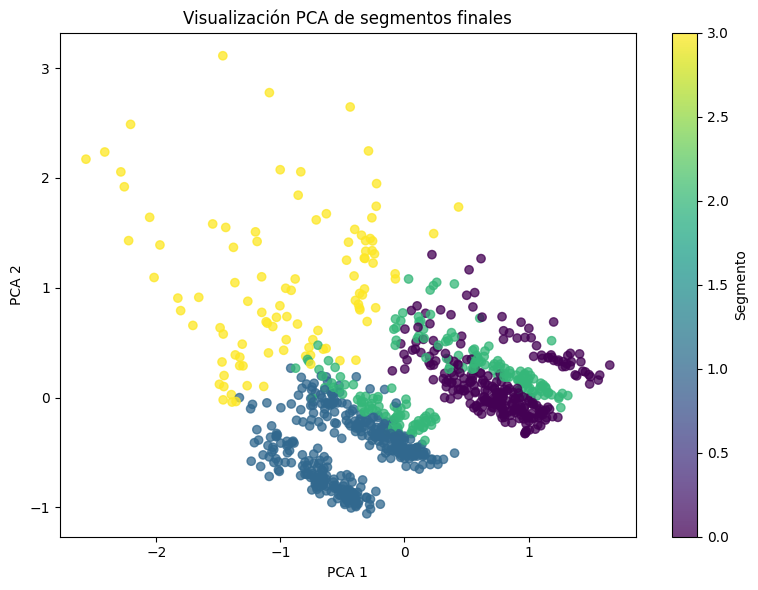

In [50]:
# Proyección PCA bidimensional para inspección visual de separabilidad de segmentos.

pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
pca_projection = pca_visual.fit_transform(X_eligible_scaled)

pca_visual_df = pd.DataFrame({
    "pca_1": pca_projection[:, 0],
    "pca_2": pca_projection[:, 1],
    "segment_id": client_segments_final["segment_id"].values,
    "segment_name": client_segments_final["segment_id"].map(segment_name_map).values
})

display(pca_visual_df.head())

pca_visual_df.to_csv(TABLES_DIR / "pca_visualizacion_segmentos_final.csv", index=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_visual_df["pca_1"],
    pca_visual_df["pca_2"],
    c=pca_visual_df["segment_id"],
    alpha=0.75
)
plt.title("Visualización PCA de segmentos finales")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Segmento")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_segmentos_finales.png", dpi=150)
plt.show()

,tsne_1,tsne_2,segment_id,segment_name
0,24.5625,1.8023,0,Clientes recurrentes diversificados de alto uso
1,-24.9288,0.8553,1,Clientes de consumo moderado matutino
2,9.9875,10.6263,3,Clientes elegibles de baja actividad
3,-2.3595,15.8842,3,Clientes elegibles de baja actividad
4,3.9597,-0.0989,3,Clientes elegibles de baja actividad


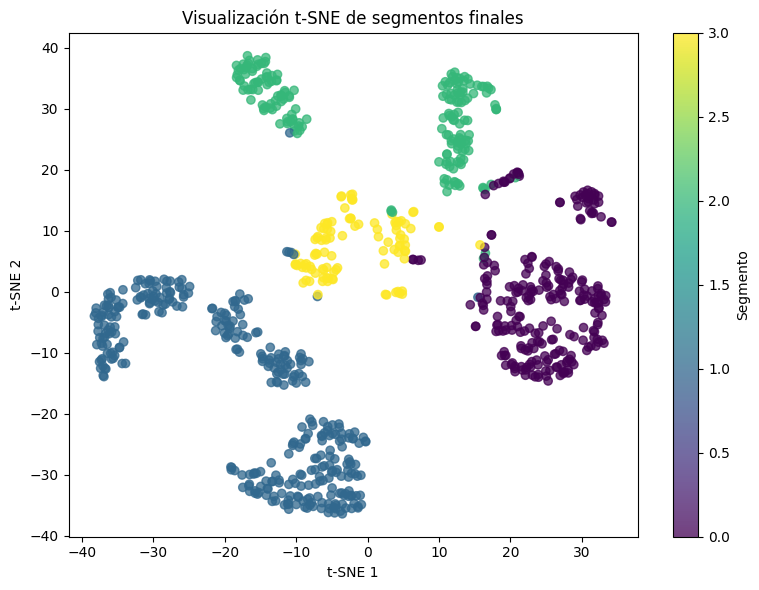

In [51]:
# Proyección t-SNE para validación visual complementaria.

from sklearn.manifold import TSNE

tsne_perplexity = min(30, max(5, (len(X_eligible_scaled) - 1) // 3))

tsne_model = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

tsne_projection = tsne_model.fit_transform(X_eligible_scaled)

tsne_visual_df = pd.DataFrame({
    "tsne_1": tsne_projection[:, 0],
    "tsne_2": tsne_projection[:, 1],
    "segment_id": client_segments_final["segment_id"].values,
    "segment_name": client_segments_final["segment_id"].map(segment_name_map).values
})

display(tsne_visual_df.head())

tsne_visual_df.to_csv(TABLES_DIR / "tsne_visualizacion_segmentos_final.csv", index=False)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    tsne_visual_df["tsne_1"],
    tsne_visual_df["tsne_2"],
    c=tsne_visual_df["segment_id"],
    alpha=0.75
)
plt.title("Visualización t-SNE de segmentos finales")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, label="Segmento")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tsne_segmentos_finales.png", dpi=150)
plt.show()

## 26. Exportación integral de resultados

Se consolida el inventario de artefactos generados por el notebook: tablas, diagnósticos, perfiles, visualizaciones y bases segmentadas.

In [52]:
# Inventario final de tablas y figuras generadas.

artifacts = sorted(TABLES_DIR.glob("*.csv")) + sorted(FIGURES_DIR.glob("*.png"))

artifacts_df = pd.DataFrame({
    "artifact": [str(artifact.relative_to(PROJECT_DIR)) for artifact in artifacts],
    "type": ["table" if artifact.suffix.lower() == ".csv" else "figure" for artifact in artifacts]
})

display(artifacts_df)

artifacts_df.to_csv(TABLES_DIR / "inventario_artefactos_generados.csv", index=False)

,artifact,type
0,outputs/tables/asimetria_variables_cliente_ele...,table
1,outputs/tables/asimetria_variables_cliente_ele...,table
2,outputs/tables/asimetria_variables_cliente_gen...,table
3,outputs/tables/asimetria_variables_cliente_gen...,table
4,outputs/tables/auditoria_etica_variables_exclu...,table
5,outputs/tables/auditoria_inicial_columnas.csv,table
6,outputs/tables/clientes_segmentados_elegible.csv,table
7,outputs/tables/clientes_segmentados_final.csv,table
8,outputs/tables/clientes_segmentados_final_con_...,table
9,outputs/tables/clientes_segmentados_general.csv,table


## 27. Operacionalización del modelo para nuevos clientes

Esta sección convierte el análisis final en un prototipo reutilizable. Al ejecutarla se genera un paquete que conserva el modelo K-Means, el escalador, los límites de winsorización, las transformaciones seleccionadas, el orden de variables, los umbrales de elegibilidad y el playbook de marketing.

El paquete permite procesar nuevos historiales transaccionales sin volver a ajustar el preprocesamiento ni reentrenar el modelo.

In [53]:
# Exportación del modelo final y del preprocesamiento aprendido.
from pathlib import Path
import importlib.metadata as importlib_metadata
import joblib
import sklearn

required_objects = [
    "X_eligible",
    "X_eligible_processed",
    "X_eligible_scaled",
    "metadata_eligible",
    "scaler_eligible",
    "candidate_segment_outputs",
    "recommended_k",
    "segment_name_map",
    "segment_business_map",
    "reference_date",
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        "Antes de exportar, ejecute el notebook completo. Faltan objetos: "
        + ", ".join(missing_objects)
    )

OPERATIONAL_K = 4
if OPERATIONAL_K not in candidate_segment_outputs:
    raise RuntimeError("No se encontró la solución candidata k=4 en el notebook.")
if int(recommended_k) != OPERATIONAL_K:
    print(
        f"Advertencia: la matriz automática recomendó k={recommended_k}; "
        "el prototipo conservará k=4, que es la solución documentada en el TFM."
    )

APP_DIR = PROJECT_DIR / "app_segmentacion_clientes"
APP_ARTIFACTS_DIR = APP_DIR / "artifacts"
APP_DATA_DIR = APP_DIR / "data"
APP_TESTS_DIR = APP_DIR / "tests"
for path in [APP_DIR, APP_ARTIFACTS_DIR, APP_DATA_DIR, APP_TESTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# El preprocesamiento original elimina primero variables excluidas por rol.
excluded_columns = list(metadata_eligible.get("excluded_by_role", []))
zero_variance_columns = list(metadata_eligible.get("dropped_zero_variance_columns", []))
X_for_bounds = X_eligible.drop(columns=excluded_columns, errors="ignore").copy()

# Los límites se calculan una sola vez sobre la muestra de entrenamiento.
winsor_bounds = {}
for col in metadata_eligible.get("winsorized_columns", []):
    if col in X_for_bounds.columns:
        winsor_bounds[col] = {
            "lower": float(X_for_bounds[col].quantile(0.01)),
            "upper": float(X_for_bounds[col].quantile(0.99)),
        }

final_model_for_app = candidate_segment_outputs[OPERATIONAL_K]["model"]
training_labels = final_model_for_app.predict(X_eligible_scaled)
training_distances = final_model_for_app.transform(X_eligible_scaled)
assigned_distances = training_distances[np.arange(len(training_labels)), training_labels]

distance_thresholds = {}
for segment_id in sorted(np.unique(training_labels)):
    segment_distances = assigned_distances[training_labels == segment_id]
    distance_thresholds[int(segment_id)] = float(np.quantile(segment_distances, 0.95))

library_versions = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": importlib_metadata.version("scipy"),
    "scikit-learn": sklearn.__version__,
    "joblib": joblib.__version__,
}

bundle = {
    "model": final_model_for_app,
    "scaler": scaler_eligible,
    "input_feature_order": X_eligible.columns.tolist(),
    "feature_order": X_eligible_processed.columns.tolist(),
    "winsor_bounds": winsor_bounds,
    "log_columns": list(metadata_eligible.get("transformed_columns", [])),
    "excluded_columns": excluded_columns,
    "zero_variance_columns": zero_variance_columns,
    "min_transactions": int(MIN_TRANSACTIONS),
    "min_lifetime_days": int(MIN_LIFETIME_DAYS),
    "training_reference_date": pd.Timestamp(reference_date).isoformat(),
    "segment_name_map": {int(k): v for k, v in segment_name_map.items()},
    "segment_business_map": {int(k): v for k, v in segment_business_map.items()},
    "distance_thresholds": distance_thresholds,
    "required_transaction_columns": [
        "cc_num",
        "trans_date_trans_time",
        "amt",
        "category",
        "merchant",
    ],
    "model_metadata": {
        "algorithm": "K-Means",
        "n_clusters": int(final_model_for_app.n_clusters),
        "random_state": int(RANDOM_STATE),
        "n_training_customers": int(len(X_eligible)),
        "quantile_range_scaler": [5.0, 95.0],
        "winsor_quantiles": [0.01, 0.99],
        "library_versions": library_versions,
    },
}

BUNDLE_PATH = APP_ARTIFACTS_DIR / "segmentation_bundle.joblib"
joblib.dump(bundle, BUNDLE_PATH)

print("Paquete del modelo guardado en:")
print(BUNDLE_PATH.resolve())
print("Variables de entrada:", len(bundle["input_feature_order"]))
print("Variables finales:", len(bundle["feature_order"]))
print("Columnas log1p:", bundle["log_columns"])
print("Columnas excluidas:", bundle["excluded_columns"])
print("Columnas sin varianza:", bundle["zero_variance_columns"])
print("Umbrales de distancia P95:", bundle["distance_thresholds"])

Paquete del modelo guardado en:
/content/app_segmentacion_clientes/artifacts/segmentation_bundle.joblib
Variables de entrada: 18
Variables finales: 16
Columnas log1p: ['ticket_std', 'ticket_max']
Columnas excluidas: ['ticket_min']
Columnas sin varianza: ['category_nunique']
Umbrales de distancia P95: {0: 1.4890720385948724, 1: 1.360695747455744, 2: 1.421935718625297, 3: 2.7661536181394917}


## 28. Generación de la aplicación Streamlit

La siguiente celda crea automáticamente la interfaz, el módulo de transformación, los archivos de instalación, un historial de ejemplo y una plantilla CSV.

In [54]:
# Creación de los archivos de la aplicación.
import shutil

embedded_files = {'segmentation_core.py': 'from __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Any\n\nimport joblib\nimport numpy as np\nimport pandas as pd\n\nREQUIRED_TRANSACTION_COLUMNS = [\n    "cc_num",\n    "trans_date_trans_time",\n    "amt",\n    "category",\n    "merchant",\n]\n\nPERIOD_COLUMNS = [\n    "txn_pct_morning",\n    "txn_pct_afternoon",\n    "txn_pct_night",\n    "txn_pct_early_morning",\n]\n\n\nclass InputValidationError(ValueError):\n    """Error de validación legible para la interfaz."""\n\n\ndef load_bundle(path: str | Path) -> dict[str, Any]:\n    """Carga el paquete persistido del modelo de segmentación."""\n    bundle_path = Path(path)\n    if not bundle_path.exists():\n        raise FileNotFoundError(\n            f"No se encontró el paquete del modelo en: {bundle_path.resolve()}"\n        )\n    return joblib.load(bundle_path)\n\n\ndef _time_period(hour: int) -> str:\n    if 6 <= hour < 12:\n        return "morning"\n    if 12 <= hour < 18:\n        return "afternoon"\n    if 18 <= hour < 24:\n        return "night"\n    return "early_morning"\n\n\ndef prepare_transactions(transactions: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:\n    """Valida y normaliza un historial transaccional cargado por el usuario."""\n    if transactions is None or transactions.empty:\n        raise InputValidationError("El archivo no contiene transacciones.")\n\n    df = transactions.copy()\n    df.columns = [str(col).strip() for col in df.columns]\n\n    missing = [col for col in REQUIRED_TRANSACTION_COLUMNS if col not in df.columns]\n    if missing:\n        raise InputValidationError(\n            "Faltan columnas requeridas: " + ", ".join(missing)\n        )\n\n    original_rows = len(df)\n    duplicate_rows = int(df.duplicated().sum())\n    if duplicate_rows:\n        df = df.drop_duplicates().copy()\n\n    df["trans_date_trans_time"] = pd.to_datetime(\n        df["trans_date_trans_time"], errors="coerce"\n    )\n    invalid_dates = int(df["trans_date_trans_time"].isna().sum())\n    if invalid_dates:\n        raise InputValidationError(\n            f"Se encontraron {invalid_dates} fechas no válidas en trans_date_trans_time."\n        )\n\n    df["amt"] = pd.to_numeric(df["amt"], errors="coerce")\n    invalid_amounts = int(df["amt"].isna().sum())\n    if invalid_amounts:\n        raise InputValidationError(\n            f"Se encontraron {invalid_amounts} montos no numéricos en amt."\n        )\n\n    null_counts = df[REQUIRED_TRANSACTION_COLUMNS].isna().sum()\n    null_columns = null_counts[null_counts > 0]\n    if not null_columns.empty:\n        detail = ", ".join(f"{col}: {int(value)}" for col, value in null_columns.items())\n        raise InputValidationError(\n            "Existen valores ausentes en columnas obligatorias: " + detail\n        )\n\n    if (df["amt"] < 0).any():\n        negative_count = int((df["amt"] < 0).sum())\n        raise InputValidationError(\n            f"Se encontraron {negative_count} montos negativos. Deben corregirse antes de segmentar."\n        )\n\n    df["cc_num"] = df["cc_num"].astype(str).str.strip()\n    df["category"] = df["category"].astype(str).str.strip()\n    df["merchant"] = df["merchant"].astype(str).str.strip()\n\n    empty_ids = int((df["cc_num"] == "").sum())\n    if empty_ids:\n        raise InputValidationError(\n            f"Se encontraron {empty_ids} identificadores de cliente vacíos."\n        )\n\n    audit = {\n        "original_rows": original_rows,\n        "duplicate_rows_removed": duplicate_rows,\n        "clean_rows": len(df),\n        "customers": int(df["cc_num"].nunique()),\n    }\n    return df.sort_values("trans_date_trans_time").reset_index(drop=True), audit\n\n\ndef transactions_to_customer_features(\n    transactions: pd.DataFrame,\n    reference_date: pd.Timestamp,\n) -> pd.DataFrame:\n    """Replica la ingeniería de variables del notebook para uno o varios clientes."""\n    df, _ = prepare_transactions(transactions)\n    reference_ts = pd.Timestamp(reference_date)\n\n    if reference_ts < df["trans_date_trans_time"].max():\n        raise InputValidationError(\n            "La fecha de corte no puede ser anterior a la última transacción cargada."\n        )\n\n    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour\n    df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek\n    df["is_weekend"] = df["transaction_dayofweek"].isin([5, 6]).astype(int)\n    df["time_period"] = df["transaction_hour"].apply(_time_period)\n\n    client_base = (\n        df.groupby("cc_num")\n        .agg(\n            first_transaction=("trans_date_trans_time", "min"),\n            last_transaction=("trans_date_trans_time", "max"),\n            frequency=("amt", "size"),\n            monetary_total=("amt", "sum"),\n            ticket_mean=("amt", "mean"),\n            ticket_median=("amt", "median"),\n            ticket_std=("amt", "std"),\n            ticket_min=("amt", "min"),\n            ticket_max=("amt", "max"),\n            category_nunique=("category", "nunique"),\n            merchant_nunique=("merchant", "nunique"),\n            weekend_txn_pct=("is_weekend", "mean"),\n        )\n        .reset_index()\n    )\n\n    client_base["recency_days"] = (\n        reference_ts - client_base["last_transaction"]\n    ).dt.days\n    client_base["customer_lifetime_days"] = (\n        client_base["last_transaction"] - client_base["first_transaction"]\n    ).dt.days + 1\n    client_base["ticket_std"] = client_base["ticket_std"].fillna(0.0)\n\n    period_pivot = df.pivot_table(\n        index="cc_num",\n        columns="time_period",\n        values="amt",\n        aggfunc="size",\n        fill_value=0,\n    )\n    period_pivot = period_pivot.div(period_pivot.sum(axis=1), axis=0)\n    period_pivot.columns = [f"txn_pct_{col}" for col in period_pivot.columns]\n\n    for col in PERIOD_COLUMNS:\n        if col not in period_pivot.columns:\n            period_pivot[col] = 0.0\n    period_pivot = period_pivot[PERIOD_COLUMNS]\n\n    client_category = (\n        df.groupby(["cc_num", "category"])\n        .agg(category_amount=("amt", "sum"), category_txn=("amt", "size"))\n        .reset_index()\n    )\n    total_by_client = client_category.groupby("cc_num")["category_amount"].transform("sum")\n    client_category["category_amount_share"] = np.where(\n        total_by_client > 0,\n        client_category["category_amount"] / total_by_client,\n        0.0,\n    )\n\n    category_concentration = (\n        client_category.sort_values(\n            ["cc_num", "category_amount_share"], ascending=[True, False]\n        )\n        .groupby("cc_num")\n        .agg(\n            top_category_share=("category_amount_share", "max"),\n            top3_category_share=("category_amount_share", lambda x: x.head(3).sum()),\n        )\n    )\n\n    dominant_category = (\n        client_category.sort_values(\n            ["cc_num", "category_amount_share"], ascending=[True, False]\n        )\n        .groupby("cc_num")\n        .first()[["category"]]\n        .rename(columns={"category": "dominant_category"})\n    )\n\n    features = (\n        client_base.set_index("cc_num")\n        .join(period_pivot, how="left")\n        .join(category_concentration, how="left")\n        .join(dominant_category, how="left")\n        .reset_index()\n    )\n\n    numeric_cols = features.select_dtypes(include=[np.number]).columns\n    features[numeric_cols] = features[numeric_cols].fillna(0.0)\n    features["dominant_category"] = features["dominant_category"].fillna("sin_categoria")\n    return features\n\n\ndef check_eligibility(features: pd.DataFrame, bundle: dict[str, Any]) -> pd.Series:\n    """Determina qué clientes cuentan con historial suficiente."""\n    return (\n        (features["frequency"] >= int(bundle["min_transactions"]))\n        & (\n            features["customer_lifetime_days"]\n            >= int(bundle["min_lifetime_days"])\n        )\n    )\n\n\ndef transform_customer_features(\n    customer_features: pd.DataFrame,\n    bundle: dict[str, Any],\n) -> pd.DataFrame:\n    """Aplica exclusivamente transformaciones aprendidas durante el entrenamiento."""\n    missing = [\n        col for col in bundle["input_feature_order"] if col not in customer_features.columns\n    ]\n    if missing:\n        raise InputValidationError(\n            "No fue posible construir las variables requeridas: " + ", ".join(missing)\n        )\n\n    X = customer_features[bundle["input_feature_order"]].copy()\n    X = X.drop(columns=bundle.get("excluded_columns", []), errors="ignore")\n\n    for col, bounds in bundle["winsor_bounds"].items():\n        if col in X.columns:\n            X[col] = X[col].clip(\n                lower=float(bounds["lower"]),\n                upper=float(bounds["upper"]),\n            )\n\n    for col in bundle.get("log_columns", []):\n        if col in X.columns:\n            if (X[col] < 0).any():\n                raise InputValidationError(\n                    f"La variable {col} contiene valores negativos y no admite log1p."\n                )\n            X[col] = np.log1p(X[col])\n\n    X = X.drop(columns=bundle.get("zero_variance_columns", []), errors="ignore")\n    X = X[bundle["feature_order"]]\n\n    scaled = bundle["scaler"].transform(X)\n    return pd.DataFrame(scaled, columns=bundle["feature_order"], index=X.index)\n\n\ndef score_transactions(\n    transactions: pd.DataFrame,\n    reference_date: pd.Timestamp,\n    bundle: dict[str, Any],\n) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:\n    """Valida, agrega, comprueba elegibilidad y asigna segmentos."""\n    clean_transactions, audit = prepare_transactions(transactions)\n    features = transactions_to_customer_features(clean_transactions, reference_date)\n    eligible = check_eligibility(features, bundle)\n\n    results = features[\n        [\n            "cc_num",\n            "frequency",\n            "customer_lifetime_days",\n            "recency_days",\n            "monetary_total",\n            "ticket_mean",\n            "merchant_nunique",\n            "category_nunique",\n            "dominant_category",\n        ]\n    ].copy()\n    results["eligible"] = eligible.values\n    results["status"] = np.where(\n        results["eligible"],\n        "Elegible para segmentación",\n        "Historial insuficiente",\n    )\n    results["segment_id"] = pd.Series([pd.NA] * len(results), dtype="Int64")\n    results["segment_name"] = "No asignado"\n    results["dominant_pattern"] = ""\n    results["business_objective"] = ""\n    results["recommended_action"] = ""\n    results["suggested_kpi"] = ""\n    results["distance_to_centroid"] = np.nan\n    results["distance_threshold_p95"] = np.nan\n    results["assignment_assessment"] = "No aplica"\n\n    if eligible.any():\n        eligible_features = features.loc[eligible].reset_index(drop=True)\n        X_scaled = transform_customer_features(eligible_features, bundle)\n        model = bundle["model"]\n        labels = model.predict(X_scaled)\n        distances = model.transform(X_scaled)\n\n        for position, segment_id in enumerate(labels):\n            target_index = results.index[eligible][position]\n            segment_id = int(segment_id)\n            assigned_distance = float(distances[position, segment_id])\n            threshold = float(bundle["distance_thresholds"][segment_id])\n            business = bundle["segment_business_map"][segment_id]\n\n            results.at[target_index, "segment_id"] = segment_id\n            results.at[target_index, "segment_name"] = bundle["segment_name_map"][segment_id]\n            results.at[target_index, "dominant_pattern"] = business["dominant_pattern"]\n            results.at[target_index, "business_objective"] = business["business_objective"]\n            results.at[target_index, "recommended_action"] = business["recommended_action"]\n            results.at[target_index, "suggested_kpi"] = business["suggested_kpi"]\n            results.at[target_index, "distance_to_centroid"] = assigned_distance\n            results.at[target_index, "distance_threshold_p95"] = threshold\n            results.at[target_index, "assignment_assessment"] = (\n                "Dentro del rango habitual del segmento"\n                if assigned_distance <= threshold\n                else "Cliente alejado del centroide; revisar asignación"\n            )\n\n    return results, features, audit\n', 'app.py': 'from __future__ import annotations\n\nfrom pathlib import Path\n\nimport pandas as pd\nimport streamlit as st\n\nfrom segmentation_core import (\n    InputValidationError,\n    REQUIRED_TRANSACTION_COLUMNS,\n    load_bundle,\n    score_transactions,\n)\n\nst.set_page_config(\n    page_title="Segmentación de clientes bancarios",\n    page_icon="📊",\n    layout="wide",\n)\n\nBASE_DIR = Path(__file__).resolve().parent\nBUNDLE_PATH = BASE_DIR / "artifacts" / "segmentation_bundle.joblib"\nEXAMPLE_PATH = BASE_DIR / "data" / "cliente_ejemplo.csv"\n\n\n@st.cache_resource\ndef get_bundle():\n    return load_bundle(BUNDLE_PATH)\n\n\nst.markdown(\n    """\n    <style>\n    .main-title {font-size: 2.2rem; font-weight: 750; color: #0B2E59; margin-bottom: 0.15rem;}\n    .subtitle {font-size: 1.05rem; color: #486581; margin-bottom: 1.2rem;}\n    .result-card {padding: 1.1rem; border: 1px solid #D6E2EE; border-radius: 14px; background: #F8FBFE;}\n    .segment-name {font-size: 1.35rem; font-weight: 750; color: #0B2E59;}\n    </style>\n    """,\n    unsafe_allow_html=True,\n)\n\nst.markdown(\n    \'<div class="main-title">Asignación de nuevos clientes a segmentos</div>\',\n    unsafe_allow_html=True,\n)\nst.markdown(\n    \'<div class="subtitle">Prototipo operativo del modelo K-Means con k = 4 desarrollado en el TFM.</div>\',\n    unsafe_allow_html=True,\n)\n\ntry:\n    bundle = get_bundle()\nexcept Exception as exc:\n    st.error(\n        "No se pudo cargar el paquete del modelo. Ejecute primero el notebook de entrenamiento "\n        "y confirme que exista artifacts/segmentation_bundle.joblib."\n    )\n    st.exception(exc)\n    st.stop()\n\nwith st.sidebar:\n    st.header("Configuración")\n    st.write(f"Modelo: **K-Means, k = {bundle[\'model\'].n_clusters}**")\n    st.write(f"Mínimo de transacciones: **{bundle[\'min_transactions\']}**")\n    st.write(f"Mínimo de días observados: **{bundle[\'min_lifetime_days\']}**")\n\n    use_training_reference = st.checkbox(\n        "Usar fecha de corte del modelo",\n        value=True,\n        help=(\n            "Recomendado para reproducir el análisis histórico. Para datos de otro periodo, "\n            "debe evaluarse el reentrenamiento del modelo."\n        ),\n    )\n\n    training_reference = pd.Timestamp(bundle["training_reference_date"])\n    if use_training_reference:\n        reference_date = training_reference\n        st.caption(f"Fecha de corte: {training_reference}")\n    else:\n        selected_date = st.date_input(\n            "Fecha de corte del análisis",\n            value=pd.Timestamp.today().date(),\n        )\n        reference_date = pd.Timestamp(selected_date) + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)\n        st.warning(\n            "La fecha de corte difiere de la usada al entrenar. Para uso productivo con datos actuales, "\n            "conviene reentrenar el modelo sobre una ventana contemporánea."\n        )\n\nst.info(\n    "La aplicación no fuerza una asignación cuando el cliente tiene menos de "\n    f"{bundle[\'min_transactions\']} transacciones o menos de "\n    f"{bundle[\'min_lifetime_days\']} días observados."\n)\n\ninput_tab, manual_tab, format_tab = st.tabs(\n    ["Importar CSV", "Introducción manual", "Formato requerido"]\n)\n\ntransactions = None\nsource_label = None\n\nwith input_tab:\n    uploaded = st.file_uploader(\n        "Seleccione un CSV con transacciones de uno o varios clientes",\n        type=["csv"],\n    )\n    if uploaded is not None:\n        try:\n            transactions = pd.read_csv(uploaded)\n            source_label = uploaded.name\n            st.success(f"Archivo cargado: {uploaded.name}")\n            st.dataframe(transactions.head(20), use_container_width=True)\n        except Exception as exc:\n            st.error("No se pudo leer el archivo CSV.")\n            st.exception(exc)\n\n    if EXAMPLE_PATH.exists():\n        example_bytes = EXAMPLE_PATH.read_bytes()\n        st.download_button(\n            "Descargar archivo de ejemplo",\n            data=example_bytes,\n            file_name="cliente_ejemplo.csv",\n            mime="text/csv",\n        )\n\nwith manual_tab:\n    st.write(\n        "Puede escribir o pegar transacciones desde Excel. Use el botón **+** de la tabla "\n        "para añadir filas. Para ser elegible, un cliente necesita al menos 30 transacciones "\n        "y 30 días observados."\n    )\n    manual_seed = pd.DataFrame(\n        {\n            "cc_num": ["CLIENTE_MANUAL"],\n            "trans_date_trans_time": ["2020-01-01 10:00:00"],\n            "amt": [50.0],\n            "category": ["grocery_pos"],\n            "merchant": ["Comercio_01"],\n        }\n    )\n    manual_data = st.data_editor(\n        manual_seed,\n        num_rows="dynamic",\n        use_container_width=True,\n        key="manual_transactions",\n    )\n    if st.checkbox("Usar los datos introducidos manualmente"):\n        transactions = manual_data\n        source_label = "Entrada manual"\n\nwith format_tab:\n    st.write("El archivo debe contener exactamente estas columnas mínimas:")\n    st.code(",".join(REQUIRED_TRANSACTION_COLUMNS), language="text")\n    st.dataframe(\n        pd.DataFrame(\n            [\n                {\n                    "cc_num": "CLIENTE_001",\n                    "trans_date_trans_time": "2020-01-01 10:30:00",\n                    "amt": 42.50,\n                    "category": "grocery_pos",\n                    "merchant": "Comercio_A",\n                },\n                {\n                    "cc_num": "CLIENTE_001",\n                    "trans_date_trans_time": "2020-01-05 18:45:00",\n                    "amt": 85.20,\n                    "category": "shopping_pos",\n                    "merchant": "Comercio_B",\n                },\n            ]\n        ),\n        use_container_width=True,\n    )\n\nanalyze = st.button(\n    "Analizar y asignar segmentos",\n    type="primary",\n    use_container_width=True,\n    disabled=transactions is None,\n)\n\nif analyze and transactions is not None:\n    try:\n        results, features, audit = score_transactions(\n            transactions=transactions,\n            reference_date=reference_date,\n            bundle=bundle,\n        )\n\n        st.subheader("Validación del archivo")\n        col1, col2, col3, col4 = st.columns(4)\n        col1.metric("Filas recibidas", audit["original_rows"])\n        col2.metric("Duplicados eliminados", audit["duplicate_rows_removed"])\n        col3.metric("Transacciones válidas", audit["clean_rows"])\n        col4.metric("Clientes", audit["customers"])\n\n        st.subheader("Resultado de segmentación")\n        display_columns = [\n            "cc_num",\n            "status",\n            "segment_id",\n            "segment_name",\n            "frequency",\n            "customer_lifetime_days",\n            "recency_days",\n            "assignment_assessment",\n        ]\n        st.dataframe(results[display_columns], use_container_width=True, hide_index=True)\n\n        for _, row in results.iterrows():\n            title = f"Cliente {row[\'cc_num\']}"\n            with st.expander(title, expanded=len(results) == 1):\n                if not bool(row["eligible"]):\n                    st.warning(\n                        "Historial insuficiente. No se asignó un cluster para evitar una clasificación poco robusta."\n                    )\n                    st.write(\n                        f"Transacciones observadas: **{int(row[\'frequency\'])}** / "\n                        f"mínimo requerido: **{bundle[\'min_transactions\']}**"\n                    )\n                    st.write(\n                        f"Días observados: **{int(row[\'customer_lifetime_days\'])}** / "\n                        f"mínimo requerido: **{bundle[\'min_lifetime_days\']}**"\n                    )\n                    continue\n\n                st.markdown(\n                    f\'<div class="result-card"><div class="segment-name">Segmento {int(row["segment_id"])} — {row["segment_name"]}</div></div>\',\n                    unsafe_allow_html=True,\n                )\n                st.write("**Patrón dominante**")\n                st.write(row["dominant_pattern"])\n                st.write("**Objetivo comercial**")\n                st.write(row["business_objective"])\n                st.write("**Acción recomendada**")\n                st.write(row["recommended_action"])\n                st.write("**KPIs sugeridos**")\n                st.write(row["suggested_kpi"])\n\n                distance_col, threshold_col = st.columns(2)\n                distance_col.metric(\n                    "Distancia al centroide",\n                    f"{row[\'distance_to_centroid\']:.3f}",\n                )\n                threshold_col.metric(\n                    "Umbral habitual (P95)",\n                    f"{row[\'distance_threshold_p95\']:.3f}",\n                )\n                if "alejado" in row["assignment_assessment"].lower():\n                    st.warning(row["assignment_assessment"])\n                else:\n                    st.success(row["assignment_assessment"])\n\n        csv_output = results.to_csv(index=False).encode("utf-8-sig")\n        st.download_button(\n            "Descargar resultados en CSV",\n            data=csv_output,\n            file_name="resultados_segmentacion.csv",\n            mime="text/csv",\n            use_container_width=True,\n        )\n\n        with st.expander("Variables agregadas calculadas"):\n            st.dataframe(features, use_container_width=True)\n\n    except InputValidationError as exc:\n        st.error(str(exc))\n    except Exception as exc:\n        st.error("Se produjo un error inesperado durante la segmentación.")\n        st.exception(exc)\n', 'README_PASO_A_PASO.md': '# Prototipo de asignación de nuevos clientes a segmentos\n\nEste proyecto convierte el modelo final del TFM en una aplicación Streamlit capaz de:\n\n1. importar transacciones de uno o varios clientes;\n2. construir sus variables comportamentales;\n3. comprobar si poseen historial suficiente;\n4. aplicar el mismo preprocesamiento usado en el entrenamiento;\n5. asignar cada cliente elegible al centroide K-Means más cercano;\n6. mostrar el nombre del segmento, la acción comercial y los KPIs sugeridos.\n\n## Antes de abrir la aplicación\n\nDebe existir este archivo:\n\n```text\nartifacts/segmentation_bundle.joblib\n```\n\nEl archivo lo genera el notebook `TFM_segmentacion_clientes_notebook_interfaz.ipynb` al ejecutar todas sus celdas.\n\n## Ejecución sencilla en Windows\n\n### Primera vez\n\n1. Descomprima la carpeta del proyecto.\n2. Abra la carpeta.\n3. Haga doble clic en `01_INSTALAR_WINDOWS.bat`.\n4. Espere a que termine la instalación. Puede tardar varios minutos.\n\n### Cada vez que quiera abrir la aplicación\n\n1. Haga doble clic en `02_EJECUTAR_APP_WINDOWS.bat`.\n2. Se abrirá una ventana del navegador.\n3. Cargue `data/cliente_ejemplo.csv` o su propio CSV.\n\n## Ejecución mediante terminal\n\n```bat\npython -m venv .venv\n.venv\\Scripts\\activate\npython -m pip install --upgrade pip\npip install -r requirements.txt\nstreamlit run app.py\n```\n\n## Formato mínimo del CSV\n\n```text\ncc_num,trans_date_trans_time,amt,category,merchant\n```\n\nEjemplo:\n\n```csv\nCLIENTE_001,2020-01-01 10:30:00,42.50,grocery_pos,Comercio_A\nCLIENTE_001,2020-01-05 18:45:00,85.20,shopping_pos,Comercio_B\n```\n\n## Criterio de elegibilidad\n\nLa aplicación solo asigna un cluster cuando el cliente tiene:\n\n- al menos 30 transacciones;\n- al menos 30 días entre su primera y última transacción.\n\nUn cliente que no cumpla estos requisitos se marca como `Historial insuficiente`.\n\n## Fecha de corte\n\nPara reproducir el modelo histórico, use la fecha de corte guardada en el paquete. Si desea usar transacciones de otro periodo, la práctica correcta es reentrenar el modelo con una ventana temporal contemporánea.\n\n## Interpretación de la distancia\n\nLa distancia al centroide no es una probabilidad. Es una medida de proximidad. Si supera el percentil 95 observado durante el entrenamiento, la aplicación advierte que el cliente es atípico respecto del segmento asignado.\n', '01_INSTALAR_WINDOWS.bat': '@echo off\ncd /d "%~dp0"\nwhere python >nul 2>nul\nif errorlevel 1 (\n  echo No se encontro Python. Instale Python 3.11 o Anaconda y vuelva a ejecutar este archivo.\n  pause\n  exit /b 1\n)\npython -m venv .venv\ncall .venv\\Scripts\\activate.bat\npython -m pip install --upgrade pip\npip install -r requirements.txt\nif errorlevel 1 (\n  echo La instalacion no termino correctamente.\n  pause\n  exit /b 1\n)\necho.\necho Instalacion completada.\npause\n', '02_EJECUTAR_APP_WINDOWS.bat': '@echo off\ncd /d "%~dp0"\nif not exist ".venv\\Scripts\\activate.bat" (\n  echo Primero ejecute 01_INSTALAR_WINDOWS.bat\n  pause\n  exit /b 1\n)\nif not exist "artifacts\\segmentation_bundle.joblib" (\n  echo No se encontro artifacts\\segmentation_bundle.joblib\n  echo Ejecute primero el notebook de entrenamiento y copie el archivo generado en la carpeta artifacts.\n  pause\n  exit /b 1\n)\ncall .venv\\Scripts\\activate.bat\nstreamlit run app.py\n', 'tests/test_core.py': 'import pandas as pd\n\nfrom segmentation_core import prepare_transactions, transactions_to_customer_features\n\n\ndef test_feature_construction():\n    rows = []\n    for i in range(35):\n        rows.append(\n            {\n                "cc_num": "TEST_001",\n                "trans_date_trans_time": f"2020-01-{(i % 28) + 1:02d} 10:00:00",\n                "amt": 20 + i,\n                "category": f"cat_{i % 4}",\n                "merchant": f"merchant_{i % 8}",\n            }\n        )\n    df = pd.DataFrame(rows)\n    clean, audit = prepare_transactions(df)\n    features = transactions_to_customer_features(clean, pd.Timestamp("2020-02-15"))\n    assert audit["customers"] == 1\n    assert int(features.loc[0, "frequency"]) == 35\n    assert int(features.loc[0, "category_nunique"]) == 4\n'}

for relative_name, content in embedded_files.items():
    destination = APP_DIR / relative_name
    destination.parent.mkdir(parents=True, exist_ok=True)
    destination.write_text(content, encoding="utf-8")

# requirements.txt conserva las versiones críticas del entorno de entrenamiento.
requirements_lines = [
    "streamlit>=1.40,<2",
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"scipy=={importlib_metadata.version('scipy')}",
    f"scikit-learn=={sklearn.__version__}",
    f"joblib=={joblib.__version__}",
]
(APP_DIR / "requirements.txt").write_text(
    "\n".join(requirements_lines) + "\n",
    encoding="utf-8",
)

# Plantilla vacía para archivos nuevos.
required_columns = bundle["required_transaction_columns"]
pd.DataFrame(columns=required_columns).to_csv(
    APP_DATA_DIR / "plantilla_transacciones.csv",
    index=False,
)

# Historial real de un cliente elegible para demostrar la aplicación.
operational_segments = candidate_segment_outputs[OPERATIONAL_K]["client_segments"].copy()
preferred_segment = 2
sample_candidates = operational_segments.loc[
    operational_segments["segment_id"] == preferred_segment,
    "cc_num",
]
if sample_candidates.empty:
    sample_customer_id = operational_segments.iloc[0]["cc_num"]
else:
    sample_customer_id = sample_candidates.iloc[0]

sample_transactions = df.loc[
    df["cc_num"] == sample_customer_id,
    required_columns,
].copy()
sample_transactions.to_csv(
    APP_DATA_DIR / "cliente_ejemplo.csv",
    index=False,
)

# Copia de la tabla de referencia para comprobar el segmento esperado.
expected_sample_segment = int(
    operational_segments.loc[
        operational_segments["cc_num"] == sample_customer_id,
        "segment_id",
    ].iloc[0]
)

# Empaquetado completo para descargar.
ZIP_BASE = PROJECT_DIR / "app_segmentacion_clientes"
ZIP_PATH = Path(shutil.make_archive(str(ZIP_BASE), "zip", root_dir=APP_DIR))

print("Archivos generados:")
for path in sorted(APP_DIR.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(PROJECT_DIR))
print("\nArchivo ZIP:")
print(ZIP_PATH.resolve())
print("Cliente de ejemplo:", sample_customer_id)
print("Segmento esperado:", expected_sample_segment)

Archivos generados:
- app_segmentacion_clientes/01_INSTALAR_WINDOWS.bat
- app_segmentacion_clientes/02_EJECUTAR_APP_WINDOWS.bat
- app_segmentacion_clientes/README_PASO_A_PASO.md
- app_segmentacion_clientes/app.py
- app_segmentacion_clientes/artifacts/segmentation_bundle.joblib
- app_segmentacion_clientes/data/cliente_ejemplo.csv
- app_segmentacion_clientes/data/plantilla_transacciones.csv
- app_segmentacion_clientes/requirements.txt
- app_segmentacion_clientes/segmentation_core.py
- app_segmentacion_clientes/tests/test_core.py

Archivo ZIP:
/content/app_segmentacion_clientes.zip
Cliente de ejemplo: 502038091380
Segmento esperado: 2


## 29. Prueba automática de consistencia

Esta comprobación procesa de nuevo el cliente de ejemplo desde sus transacciones y verifica que la aplicación recupere el mismo segmento que el notebook.

In [55]:
# Prueba de extremo a extremo antes de utilizar la interfaz.
import importlib.util

module_path = APP_DIR / "segmentation_core.py"
spec = importlib.util.spec_from_file_location("segmentation_core_generated", module_path)
segmentation_core_generated = importlib.util.module_from_spec(spec)
spec.loader.exec_module(segmentation_core_generated)

loaded_bundle = joblib.load(BUNDLE_PATH)
example_df = pd.read_csv(APP_DATA_DIR / "cliente_ejemplo.csv")

scoring_results, scoring_features, scoring_audit = segmentation_core_generated.score_transactions(
    transactions=example_df,
    reference_date=pd.Timestamp(loaded_bundle["training_reference_date"]),
    bundle=loaded_bundle,
)

obtained_segment = int(scoring_results.loc[0, "segment_id"])
assert obtained_segment == expected_sample_segment, (
    f"La prueba no coincide: esperado={expected_sample_segment}, obtenido={obtained_segment}"
)

print("PRUEBA SUPERADA")
print("Cliente:", scoring_results.loc[0, "cc_num"])
print("Segmento recuperado:", obtained_segment)
print("Nombre:", scoring_results.loc[0, "segment_name"])
print("Evaluación de distancia:", scoring_results.loc[0, "assignment_assessment"])
display(scoring_results)

PRUEBA SUPERADA
Cliente: 502038091380
Segmento recuperado: 2
Nombre: Clientes de alto valor transaccional
Evaluación de distancia: Dentro del rango habitual del segmento


,cc_num,frequency,customer_lifetime_days,recency_days,monetary_total,ticket_mean,merchant_nunique,category_nunique,dominant_category,eligible,status,segment_id,segment_name,dominant_pattern,business_objective,recommended_action,suggested_kpi,distance_to_centroid,distance_threshold_p95,assignment_assessment
0,502038091380,1574,538,1,"145,935.2300",92.7162,592,14,travel,True,Elegible para segmentación,2,Clientes de alto valor transaccional,"Mayor gasto total, ticket promedio y ticket me...","Fidelización de alto valor, retención y venta ...","Ofrecer beneficios preferenciales, programas d...",Gasto promedio mensual; retención de clientes ...,0.8825,1.4219,Dentro del rango habitual del segmento


## 30. Descarga del prototipo

En Google Colab, la celda siguiente inicia la descarga del archivo ZIP. En Jupyter local, muestra la ruta donde se guardó.

In [56]:
# Descarga automática cuando el notebook se ejecuta en Google Colab.
try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except ImportError:
    print("El prototipo está disponible en:")
    print(ZIP_PATH.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Validación funcional con clientes reales de los cuatro segmentos

Esta validación selecciona automáticamente un cliente real y representativo de cada segmento de la muestra de entrenamiento. Para reducir el riesgo de escoger observaciones fronterizas o atípicas, se elige en cada segmento el cliente situado a menor distancia de su centroide.

El procedimiento genera:

- un CSV con el historial transaccional completo de cuatro clientes reales;
- una tabla con los segmentos esperados;
- una tabla con los segmentos recuperados mediante el mismo motor de la aplicación;
- un archivo ZIP con todos los elementos de validación.

La prueba se considera superada cuando la interfaz recupera para los cuatro clientes el mismo segmento registrado en el modelo final.

In [57]:
# Selección de un cliente real representativo por cada segmento final.

required_validation_objects = [
    "df",
    "X_eligible_scaled",
    "client_segments_final_named",
    "candidate_segment_outputs",
    "BUNDLE_PATH",
    "APP_DIR",
    "APP_DATA_DIR",
    "segmentation_core_generated",
]
missing_validation_objects = [
    name for name in required_validation_objects if name not in globals()
]
if missing_validation_objects:
    raise RuntimeError(
        "Ejecute previamente todas las celdas del notebook. Faltan objetos: "
        + ", ".join(missing_validation_objects)
    )

validation_bundle = joblib.load(BUNDLE_PATH)
validation_model = candidate_segment_outputs[4]["model"]

validation_labels = validation_model.predict(X_eligible_scaled)
validation_distance_matrix = validation_model.transform(X_eligible_scaled)
validation_assigned_distances = validation_distance_matrix[
    np.arange(len(validation_labels)),
    validation_labels,
]

validation_clients = (
    client_segments_final_named[
        [
            "cc_num",
            "segment_id",
            "segment_name",
            "frequency",
            "customer_lifetime_days",
            "recency_days",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

if len(validation_clients) != len(validation_labels):
    raise RuntimeError(
        "La matriz de clientes y las etiquetas del modelo no tienen la misma longitud."
    )

validation_clients["segment_id_model_check"] = validation_labels.astype(int)
validation_clients["distance_to_centroid"] = validation_assigned_distances

if not (
    validation_clients["segment_id"].astype(int)
    == validation_clients["segment_id_model_check"]
).all():
    raise RuntimeError(
        "Las etiquetas registradas no coinciden con las predicciones del modelo final."
    )

representative_clients = (
    validation_clients
    .sort_values(["segment_id", "distance_to_centroid"])
    .groupby("segment_id", as_index=False)
    .head(1)
    .sort_values("segment_id")
    .reset_index(drop=True)
)

expected_segments = set(range(4))
selected_segments = set(representative_clients["segment_id"].astype(int))
if selected_segments != expected_segments:
    raise RuntimeError(
        f"No fue posible seleccionar un cliente para cada segmento. "
        f"Segmentos encontrados: {sorted(selected_segments)}"
    )

representative_clients["distance_threshold_p95"] = representative_clients[
    "segment_id"
].astype(int).map(validation_bundle["distance_thresholds"])

representative_clients["expected_assessment"] = np.where(
    representative_clients["distance_to_centroid"]
    <= representative_clients["distance_threshold_p95"],
    "Dentro del rango habitual del segmento",
    "Cliente alejado del centroide; revisar asignación",
)

display(representative_clients)

,cc_num,segment_id,segment_name,frequency,customer_lifetime_days,recency_days,segment_id_model_check,distance_to_centroid,distance_threshold_p95,expected_assessment
0,4198470814557,0,Clientes recurrentes diversificados de alto uso,2028,538,1,0,0.3146,1.4891,Dentro del rango habitual del segmento
1,4355790796238264643,1,Clientes de consumo moderado matutino,1506,538,1,1,0.3519,1.3607,Dentro del rango habitual del segmento
2,4926376199189801,2,Clientes de alto valor transaccional,1565,537,1,2,0.3432,1.4219,Dentro del rango habitual del segmento
3,4980323467523543940,3,Clientes elegibles de baja actividad,532,535,2,3,0.4648,2.7662,Dentro del rango habitual del segmento


In [58]:
# Exportación del historial completo de los cuatro clientes seleccionados.

def normalize_customer_id(value):
    """Normaliza identificadores para evitar diferencias entre enteros y texto."""
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.endswith(".0") and text[:-2].isdigit():
        text = text[:-2]
    return text

selected_customer_ids = set(
    representative_clients["cc_num"].map(normalize_customer_id)
)

validation_transactions = df[
    ["cc_num", "trans_date_trans_time", "amt", "category", "merchant"]
].copy()

validation_transactions["cc_num"] = validation_transactions["cc_num"].map(
    normalize_customer_id
)

validation_transactions = (
    validation_transactions[
        validation_transactions["cc_num"].isin(selected_customer_ids)
    ]
    .sort_values(["cc_num", "trans_date_trans_time"])
    .reset_index(drop=True)
)

transactions_per_customer = (
    validation_transactions.groupby("cc_num").size().rename("exported_transactions")
)

expected_labels = representative_clients.copy()
expected_labels["cc_num"] = expected_labels["cc_num"].map(normalize_customer_id)
expected_labels = expected_labels.merge(
    transactions_per_customer,
    left_on="cc_num",
    right_index=True,
    how="left",
)

if expected_labels["exported_transactions"].isna().any():
    raise RuntimeError(
        "No se encontraron transacciones para uno o más clientes seleccionados."
    )

validation_csv_path = APP_DATA_DIR / "prueba_real_4_segmentos.csv"
expected_csv_path = APP_DATA_DIR / "etiquetas_esperadas_4_segmentos.csv"

validation_transactions.to_csv(validation_csv_path, index=False)
expected_labels[
    [
        "cc_num",
        "segment_id",
        "segment_name",
        "frequency",
        "customer_lifetime_days",
        "recency_days",
        "distance_to_centroid",
        "distance_threshold_p95",
        "expected_assessment",
        "exported_transactions",
    ]
].rename(
    columns={
        "segment_id": "expected_segment_id",
        "segment_name": "expected_segment_name",
    }
).to_csv(expected_csv_path, index=False)

print("Archivo de transacciones:")
print(validation_csv_path.resolve())
print("\nEtiquetas esperadas:")
print(expected_csv_path.resolve())
print("\nTransacciones exportadas:", len(validation_transactions))
display(expected_labels)

Archivo de transacciones:
/content/app_segmentacion_clientes/data/prueba_real_4_segmentos.csv

Etiquetas esperadas:
/content/app_segmentacion_clientes/data/etiquetas_esperadas_4_segmentos.csv

Transacciones exportadas: 5631


,cc_num,segment_id,segment_name,frequency,customer_lifetime_days,recency_days,segment_id_model_check,distance_to_centroid,distance_threshold_p95,expected_assessment,exported_transactions
0,4198470814557,0,Clientes recurrentes diversificados de alto uso,2028,538,1,0,0.3146,1.4891,Dentro del rango habitual del segmento,2028
1,4355790796238264643,1,Clientes de consumo moderado matutino,1506,538,1,1,0.3519,1.3607,Dentro del rango habitual del segmento,1506
2,4926376199189801,2,Clientes de alto valor transaccional,1565,537,1,2,0.3432,1.4219,Dentro del rango habitual del segmento,1565
3,4980323467523543940,3,Clientes elegibles de baja actividad,532,535,2,3,0.4648,2.7662,Dentro del rango habitual del segmento,532


In [59]:
# Comprobación automática con el mismo motor utilizado por la aplicación Streamlit.

validation_results, validation_features, validation_audit = (
    segmentation_core_generated.score_transactions(
        transactions=validation_transactions,
        reference_date=pd.Timestamp(
            validation_bundle["training_reference_date"]
        ),
        bundle=validation_bundle,
    )
)

expected_comparison = pd.read_csv(expected_csv_path, dtype={"cc_num": str})
validation_results["cc_num"] = validation_results["cc_num"].astype(str)

comparison_4_segments = expected_comparison.merge(
    validation_results[
        [
            "cc_num",
            "status",
            "segment_id",
            "segment_name",
            "frequency",
            "customer_lifetime_days",
            "distance_to_centroid",
            "distance_threshold_p95",
            "assignment_assessment",
        ]
    ],
    on="cc_num",
    how="left",
    suffixes=("_expected", "_obtained"),
)

comparison_4_segments["segment_match"] = (
    comparison_4_segments["expected_segment_id"].astype("Int64")
    == comparison_4_segments["segment_id"].astype("Int64")
)

comparison_4_segments["name_match"] = (
    comparison_4_segments["expected_segment_name"]
    == comparison_4_segments["segment_name"]
)

comparison_4_segments["eligible_match"] = (
    comparison_4_segments["status"] == "Elegible para segmentación"
)

comparison_4_segments["validation_passed"] = (
    comparison_4_segments[
        ["segment_match", "name_match", "eligible_match"]
    ].all(axis=1)
)

results_validation_path = APP_DATA_DIR / "resultados_validacion_4_segmentos.csv"
comparison_4_segments.to_csv(results_validation_path, index=False)

display(comparison_4_segments)

if not comparison_4_segments["validation_passed"].all():
    raise AssertionError(
        "La validación no recuperó correctamente todos los segmentos."
    )

print("PRUEBA DE CUATRO SEGMENTOS SUPERADA")
print(
    f"Clientes validados: {len(comparison_4_segments)} | "
    f"Segmentos recuperados: "
    f"{sorted(comparison_4_segments['segment_id'].astype(int).tolist())}"
)

,cc_num,expected_segment_id,expected_segment_name,frequency_expected,customer_lifetime_days_expected,recency_days,distance_to_centroid_expected,distance_threshold_p95_expected,expected_assessment,exported_transactions,status,segment_id,segment_name,frequency_obtained,customer_lifetime_days_obtained,distance_to_centroid_obtained,distance_threshold_p95_obtained,assignment_assessment,segment_match,name_match,eligible_match,validation_passed
0,4198470814557,0,Clientes recurrentes diversificados de alto uso,2028,538,1,0.3146,1.4891,Dentro del rango habitual del segmento,2028,Elegible para segmentación,0,Clientes recurrentes diversificados de alto uso,2028,538,0.3146,1.4891,Dentro del rango habitual del segmento,True,True,True,True
1,4355790796238264643,1,Clientes de consumo moderado matutino,1506,538,1,0.3519,1.3607,Dentro del rango habitual del segmento,1506,Elegible para segmentación,1,Clientes de consumo moderado matutino,1506,538,0.3519,1.3607,Dentro del rango habitual del segmento,True,True,True,True
2,4926376199189801,2,Clientes de alto valor transaccional,1565,537,1,0.3432,1.4219,Dentro del rango habitual del segmento,1565,Elegible para segmentación,2,Clientes de alto valor transaccional,1565,537,0.3432,1.4219,Dentro del rango habitual del segmento,True,True,True,True
3,4980323467523543940,3,Clientes elegibles de baja actividad,532,535,2,0.4648,2.7662,Dentro del rango habitual del segmento,532,Elegible para segmentación,3,Clientes elegibles de baja actividad,532,535,0.4648,2.7662,Dentro del rango habitual del segmento,True,True,True,True


PRUEBA DE CUATRO SEGMENTOS SUPERADA
Clientes validados: 4 | Segmentos recuperados: [0, 1, 2, 3]


In [60]:
# Creación de un paquete descargable con los archivos necesarios para la prueba.

import zipfile

validation_readme_path = APP_DATA_DIR / "INSTRUCCIONES_PRUEBA_4_SEGMENTOS.txt"
validation_readme_path.write_text(
    """
PRUEBA FUNCIONAL CON CLIENTES REALES DE LOS CUATRO SEGMENTOS

1. Abra la aplicación Streamlit.
2. Mantenga activada la opción "Usar fecha de corte del modelo".
3. Cargue el archivo prueba_real_4_segmentos.csv.
4. Pulse "Analizar y asignar segmentos".
5. Compare los resultados con etiquetas_esperadas_4_segmentos.csv.
6. Los cuatro clientes deben ser elegibles.
7. Debe aparecer exactamente un cliente en cada segmento: 0, 1, 2 y 3.
8. Descargue el resultado de la aplicación y consérvelo como evidencia.

El archivo resultados_validacion_4_segmentos.csv contiene la comprobación
automática realizada en el notebook.
""".strip(),
    encoding="utf-8",
)

validation_zip_path = PROJECT_DIR / "prueba_validacion_real_4_segmentos.zip"

with zipfile.ZipFile(
    validation_zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in [
        validation_csv_path,
        expected_csv_path,
        results_validation_path,
        validation_readme_path,
    ]:
        archive.write(file_path, arcname=file_path.name)

print("Paquete de validación generado:")
print(validation_zip_path.resolve())

try:
    from google.colab import files
    files.download(str(validation_zip_path))
except Exception:
    print(
        "La descarga automática solo se activa en Google Colab. "
        "El ZIP está disponible en la ruta mostrada."
    )

Paquete de validación generado:
/content/prueba_validacion_real_4_segmentos.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Validación fuera de muestra a nivel cliente

La prueba anterior verificó que la aplicación reproduce correctamente las asignaciones del modelo para clientes conocidos. Esta sección añade una validación más exigente: en cada repetición se reserva un 20 % de los clientes elegibles, se ajusta un modelo de validación únicamente con el 80 % restante y se asignan los clientes reservados sin utilizarlos durante el ajuste.

Dado que el clustering no dispone de etiquetas verdaderas, las asignaciones fuera de muestra se comparan con la partición final del TFM como referencia estructural. Se utilizan:

- Índice de Rand Ajustado (ARI), que no depende del número asignado a cada cluster;
- información mutua normalizada (NMI);
- concordancia después de alinear las etiquetas mediante el algoritmo húngaro;
- proporción de clientes dentro del rango habitual de distancia al centroide;
- cobertura de los cuatro segmentos.

Esta validación no sustituye una prueba con datos bancarios reales futuros, pero permite comprobar si la estructura aprendida se mantiene al excluir clientes del proceso de ajuste.

In [61]:
# Funciones para ajustar y aplicar el preprocesamiento sin fuga de información.

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import contingency_matrix

def fit_holdout_preprocessor(
    X_train: pd.DataFrame,
    skew_threshold: float = 1.0,
    winsor_lower: float = 0.01,
    winsor_upper: float = 0.99,
):
    """
    Ajusta el preprocesamiento exclusivamente con clientes de entrenamiento.
    Devuelve la matriz procesada y todos los parámetros necesarios para transformar
    clientes reservados sin recalcular estadísticas sobre ellos.
    """
    X_work = X_train.copy()
    roles = classify_feature_roles(X_work.columns)

    excluded_columns = [
        col for col, role in roles.items() if role == "excluded"
    ]
    X_work = X_work.drop(columns=excluded_columns, errors="ignore")

    skewness_before = compute_skewness(X_work)
    skew_map = dict(
        zip(skewness_before["feature"], skewness_before["skewness"])
    )

    winsor_roles = {"monetary", "intensity", "diversity"}
    winsor_columns = [
        col for col in X_work.columns
        if roles.get(col) in winsor_roles
    ]

    winsor_bounds = {}
    for col in winsor_columns:
        lower = float(X_work[col].quantile(winsor_lower))
        upper = float(X_work[col].quantile(winsor_upper))
        winsor_bounds[col] = {"lower": lower, "upper": upper}
        X_work[col] = X_work[col].clip(lower=lower, upper=upper)

    transform_roles = {"monetary", "intensity"}
    log_columns = [
        col for col in X_work.columns
        if roles.get(col) in transform_roles
        and skew_map.get(col, 0.0) > skew_threshold
        and (X_work[col] >= 0).all()
    ]

    for col in log_columns:
        X_work[col] = np.log1p(X_work[col])

    zero_variance_columns = (
        X_work.nunique(dropna=True)
        .loc[lambda s: s <= 1]
        .index
        .tolist()
    )
    X_work = X_work.drop(columns=zero_variance_columns, errors="ignore")

    feature_order = X_work.columns.tolist()

    scaler = RobustScaler(quantile_range=(5.0, 95.0))
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_work),
        columns=feature_order,
        index=X_work.index,
    )

    state = {
        "excluded_columns": excluded_columns,
        "winsor_bounds": winsor_bounds,
        "log_columns": log_columns,
        "zero_variance_columns": zero_variance_columns,
        "feature_order": feature_order,
        "scaler": scaler,
    }

    return X_scaled, state


def transform_holdout_customers(
    X_new: pd.DataFrame,
    state: dict,
) -> pd.DataFrame:
    """Aplica a clientes reservados únicamente parámetros aprendidos en entrenamiento."""
    X_work = X_new.copy()

    X_work = X_work.drop(
        columns=state["excluded_columns"],
        errors="ignore",
    )

    for col, bounds in state["winsor_bounds"].items():
        if col in X_work.columns:
            X_work[col] = X_work[col].clip(
                lower=bounds["lower"],
                upper=bounds["upper"],
            )

    for col in state["log_columns"]:
        if col in X_work.columns:
            X_work[col] = np.log1p(X_work[col])

    X_work = X_work.drop(
        columns=state["zero_variance_columns"],
        errors="ignore",
    )

    missing = [
        col for col in state["feature_order"]
        if col not in X_work.columns
    ]
    if missing:
        raise RuntimeError(
            "Faltan variables necesarias para transformar clientes reservados: "
            + ", ".join(missing)
        )

    X_work = X_work[state["feature_order"]]

    return pd.DataFrame(
        state["scaler"].transform(X_work),
        columns=state["feature_order"],
        index=X_work.index,
    )


def align_cluster_labels(
    reference_labels: np.ndarray,
    candidate_labels: np.ndarray,
) -> dict[int, int]:
    """
    Alinea etiquetas arbitrarias de un modelo candidato con las etiquetas del
    modelo final usando máxima coincidencia sobre clientes de entrenamiento.
    """
    matrix = contingency_matrix(reference_labels, candidate_labels)
    row_idx, col_idx = linear_sum_assignment(-matrix)

    mapping = {
        int(candidate_cluster): int(reference_cluster)
        for reference_cluster, candidate_cluster in zip(row_idx, col_idx)
    }
    return mapping

In [62]:
# Validación repetida con reserva del 20 % de clientes elegibles.

required_holdout_objects = [
    "X_eligible",
    "X_eligible_scaled",
    "candidate_segment_outputs",
    "RANDOM_STATE",
]
missing_holdout_objects = [
    name for name in required_holdout_objects if name not in globals()
]
if missing_holdout_objects:
    raise RuntimeError(
        "Ejecute previamente todas las celdas del notebook. Faltan objetos: "
        + ", ".join(missing_holdout_objects)
    )

FINAL_K = 4
HOLDOUT_FRACTION = 0.20
N_HOLDOUT_REPEATS = 20

final_reference_model = candidate_segment_outputs[FINAL_K]["model"]
reference_labels_all = final_reference_model.predict(X_eligible_scaled).astype(int)

holdout_rows = []
holdout_details = {}

all_positions = np.arange(len(X_eligible))

for repeat in range(N_HOLDOUT_REPEATS):
    split_seed = RANDOM_STATE + repeat

    train_positions, test_positions = train_test_split(
        all_positions,
        test_size=HOLDOUT_FRACTION,
        random_state=split_seed,
        stratify=reference_labels_all,
    )

    X_train_raw = X_eligible.iloc[train_positions].copy()
    X_test_raw = X_eligible.iloc[test_positions].copy()

    y_train_reference = reference_labels_all[train_positions]
    y_test_reference = reference_labels_all[test_positions]

    X_train_scaled_holdout, preprocessor_state = fit_holdout_preprocessor(
        X_train_raw
    )
    X_test_scaled_holdout = transform_holdout_customers(
        X_test_raw,
        preprocessor_state,
    )

    validation_model = KMeans(
        n_clusters=FINAL_K,
        random_state=split_seed,
        n_init=20,
    )
    train_candidate_labels = validation_model.fit_predict(
        X_train_scaled_holdout
    )
    test_candidate_labels = validation_model.predict(
        X_test_scaled_holdout
    )

    label_mapping = align_cluster_labels(
        y_train_reference,
        train_candidate_labels,
    )

    mapped_test_labels = np.array(
        [label_mapping[int(label)] for label in test_candidate_labels],
        dtype=int,
    )

    ari = adjusted_rand_score(
        y_test_reference,
        mapped_test_labels,
    )
    nmi = normalized_mutual_info_score(
        y_test_reference,
        mapped_test_labels,
    )
    mapped_accuracy = float(
        np.mean(y_test_reference == mapped_test_labels)
    )

    train_distances = validation_model.transform(
        X_train_scaled_holdout
    )
    train_assigned_distances = train_distances[
        np.arange(len(train_candidate_labels)),
        train_candidate_labels,
    ]

    candidate_thresholds = {}
    for candidate_cluster in range(FINAL_K):
        cluster_distances = train_assigned_distances[
            train_candidate_labels == candidate_cluster
        ]
        candidate_thresholds[candidate_cluster] = float(
            np.quantile(cluster_distances, 0.95)
        )

    test_distances = validation_model.transform(
        X_test_scaled_holdout
    )
    test_assigned_distances = test_distances[
        np.arange(len(test_candidate_labels)),
        test_candidate_labels,
    ]
    test_thresholds = np.array(
        [
            candidate_thresholds[int(label)]
            for label in test_candidate_labels
        ]
    )
    in_range = test_assigned_distances <= test_thresholds

    represented_reference_segments = sorted(
        np.unique(y_test_reference).tolist()
    )
    represented_predicted_segments = sorted(
        np.unique(mapped_test_labels).tolist()
    )

    holdout_rows.append({
        "repeat": repeat + 1,
        "random_state": split_seed,
        "n_train_customers": len(train_positions),
        "n_holdout_customers": len(test_positions),
        "ari": ari,
        "nmi": nmi,
        "mapped_accuracy": mapped_accuracy,
        "pct_within_centroid_p95": float(in_range.mean() * 100),
        "reference_segments_in_holdout": len(represented_reference_segments),
        "predicted_segments_in_holdout": len(represented_predicted_segments),
        "all_four_segments_recovered": (
            set(represented_predicted_segments) == set(range(FINAL_K))
        ),
    })

    holdout_details[repeat + 1] = {
        "train_positions": train_positions,
        "test_positions": test_positions,
        "reference_labels": y_test_reference,
        "predicted_labels": mapped_test_labels,
        "distances": test_assigned_distances,
        "thresholds": test_thresholds,
        "in_range": in_range,
        "label_mapping": label_mapping,
    }

holdout_validation_df = pd.DataFrame(holdout_rows)

display(holdout_validation_df)

holdout_summary_df = (
    holdout_validation_df[
        [
            "ari",
            "nmi",
            "mapped_accuracy",
            "pct_within_centroid_p95",
        ]
    ]
    .agg(["mean", "std", "min", "median", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display(holdout_summary_df)

print(
    "Repeticiones con los cuatro segmentos recuperados:",
    int(holdout_validation_df["all_four_segments_recovered"].sum()),
    "de",
    N_HOLDOUT_REPEATS,
)

,repeat,random_state,n_train_customers,n_holdout_customers,ari,nmi,mapped_accuracy,pct_within_centroid_p95,reference_segments_in_holdout,predicted_segments_in_holdout,all_four_segments_recovered
0,1,42,726,182,0.9708,0.9586,0.9890,93.9560,4,4,True
1,2,43,726,182,0.9254,0.9235,0.9670,93.9560,4,4,True
2,3,44,726,182,1.0000,1.0000,1.0000,91.7582,4,4,True
3,4,45,726,182,1.0000,1.0000,1.0000,93.9560,4,4,True
4,5,46,726,182,1.0000,1.0000,1.0000,96.7033,4,4,True
5,6,47,726,182,0.9868,0.9797,0.9945,92.3077,4,4,True
6,7,48,726,182,0.9733,0.9601,0.9890,93.9560,4,4,True
7,8,49,726,182,1.0000,1.0000,1.0000,98.3516,4,4,True
8,9,50,726,182,0.9610,0.9550,0.9835,96.1538,4,4,True
9,10,51,726,182,0.8983,0.8777,0.9560,92.8571,4,4,True


,metric,mean,std,min,median,max
0,ari,0.9747,0.0315,0.8983,0.9883,1.0000
1,nmi,0.9681,0.0379,0.8777,0.9804,1.0000
2,mapped_accuracy,0.9893,0.0134,0.9560,0.9945,1.0000
3,pct_within_centroid_p95,94.1209,1.8013,90.6593,93.9560,98.3516


Repeticiones con los cuatro segmentos recuperados: 20 de 20


### Interpretación de la validación fuera de muestra

El ARI y la NMI se interpretan en una escala donde valores cercanos a 1 indican alta concordancia entre particiones. La exactitud alineada facilita la lectura, pero no debe interpretarse como una métrica supervisada con etiquetas verdaderas: la referencia es la partición final del TFM.

Una variación moderada entre repeticiones es esperable porque cada modelo de validación se ajusta con una muestra menor. La evidencia más favorable es una combinación de:

- ARI y NMI elevados;
- recuperación de los cuatro segmentos;
- alta proporción de clientes dentro del rango P95 de distancia;
- resultados consistentes entre repeticiones.

In [63]:
# Exportación de resultados y selección de una repetición representativa.

HOLDOUT_OUTPUT_DIR = PROJECT_DIR / "outputs" / "holdout_validation"
HOLDOUT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

holdout_results_path = (
    HOLDOUT_OUTPUT_DIR / "validacion_holdout_repeticiones.csv"
)
holdout_summary_path = (
    HOLDOUT_OUTPUT_DIR / "validacion_holdout_resumen.csv"
)

holdout_validation_df.to_csv(holdout_results_path, index=False)
holdout_summary_df.to_csv(holdout_summary_path, index=False)

median_ari = holdout_validation_df["ari"].median()
representative_repeat = int(
    (
        holdout_validation_df["ari"] - median_ari
    )
    .abs()
    .idxmin()
) + 1

representative_detail = holdout_details[representative_repeat]
representative_test_positions = representative_detail["test_positions"]

representative_customers_df = pd.DataFrame({
    "customer_index": X_eligible.index[representative_test_positions],
    "reference_segment_id": representative_detail["reference_labels"],
    "predicted_segment_id": representative_detail["predicted_labels"],
    "distance_to_centroid": representative_detail["distances"],
    "distance_threshold_p95": representative_detail["thresholds"],
    "within_centroid_p95": representative_detail["in_range"],
})

representative_customers_df["segment_match"] = (
    representative_customers_df["reference_segment_id"]
    == representative_customers_df["predicted_segment_id"]
)

representative_customers_path = (
    HOLDOUT_OUTPUT_DIR
    / "validacion_holdout_clientes_repeticion_representativa.csv"
)
representative_customers_df.to_csv(
    representative_customers_path,
    index=False,
)

print("Repetición representativa:", representative_repeat)
display(
    holdout_validation_df.loc[
        holdout_validation_df["repeat"] == representative_repeat
    ]
)
display(representative_customers_df.head(20))

Repetición representativa: 6


,repeat,random_state,n_train_customers,n_holdout_customers,ari,nmi,mapped_accuracy,pct_within_centroid_p95,reference_segments_in_holdout,predicted_segments_in_holdout,all_four_segments_recovered
5,6,47,726,182,0.9868,0.9797,0.9945,92.3077,4,4,True


,customer_index,reference_segment_id,predicted_segment_id,distance_to_centroid,distance_threshold_p95,within_centroid_p95,segment_match
0,502,1,1,0.7711,1.3533,True,True
1,710,3,3,1.3108,2.7291,True,True
2,703,0,0,1.1746,1.4255,True,True
3,253,2,2,0.9301,1.4310,True,True
4,547,2,2,1.3079,1.4310,True,True
5,313,1,1,0.5037,1.3533,True,True
6,685,0,0,1.5699,1.4255,False,True
7,804,1,1,0.6781,1.3533,True,True
8,893,2,2,0.6204,1.4310,True,True
9,518,3,3,1.2059,2.7291,True,True


In [64]:
# Paquete descargable de evidencia de validación fuera de muestra.

import zipfile

holdout_readme_path = (
    HOLDOUT_OUTPUT_DIR / "LEEME_VALIDACION_HOLDOUT.txt"
)

holdout_readme_path.write_text(
    f"""
VALIDACIÓN FUERA DE MUESTRA A NIVEL CLIENTE

Configuración:
- Clientes elegibles totales: {len(X_eligible)}
- Proporción reservada por repetición: {HOLDOUT_FRACTION:.0%}
- Número de repeticiones: {N_HOLDOUT_REPEATS}
- Número de clusters: {FINAL_K}

Procedimiento:
1. Se reserva de forma estratificada un 20 % de clientes.
2. El preprocesamiento se ajusta únicamente con el 80 % restante.
3. Se entrena K-Means con k = 4 solo sobre clientes de entrenamiento.
4. Se asignan los clientes reservados sin recalcular winsorización ni escalado.
5. Las etiquetas se alinean con la partición final mediante el algoritmo húngaro.
6. Se calculan ARI, NMI, concordancia alineada y distancia al centroide.

Limitación:
La partición final del TFM se usa como referencia estructural; no constituye una
etiqueta verdadera externa. Esta prueba evalúa consistencia fuera de muestra,
no capacidad predictiva supervisada.

Repetición representativa:
{representative_repeat}
""".strip(),
    encoding="utf-8",
)

holdout_zip_path = (
    PROJECT_DIR / "validacion_fuera_de_muestra_clientes.zip"
)

with zipfile.ZipFile(
    holdout_zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for file_path in [
        holdout_results_path,
        holdout_summary_path,
        representative_customers_path,
        holdout_readme_path,
    ]:
        archive.write(file_path, arcname=file_path.name)

print("Paquete de validación generado:")
print(holdout_zip_path.resolve())

try:
    from google.colab import files
    files.download(str(holdout_zip_path))
except Exception:
    print(
        "La descarga automática solo se activa en Google Colab. "
        "El ZIP está disponible en la ruta mostrada."
    )

Paquete de validación generado:
/content/validacion_fuera_de_muestra_clientes.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>